# Ethereum (ETH-USD) Performance & USD Correlation Analysis
### Period: 1 January 2021 → 1 January 2026

---

## Objective
1. Measure ETH monthly and annual returns in USD terms.
2. Quantify risk-adjusted performance (Sharpe, Sortino, Calmar).
3. Assess whether ETH acts as a hedge or an amplifier relative to the USD (via the DXY index).

---

## Mathematical Notation

| Symbol | Definition |
|--------|-----------|
| $P_t$ | Adjusted closing price at time $t$ |
| $r_t$ | Simple monthly return: $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$ |
| $\bar{R}_{geo}$ | Geometric mean annual return: $\bar{R}_{geo} = \left(\prod_{t=1}^{n}(1+r_t)\right)^{12/n} - 1$ |
| $\sigma$ | Annualised volatility: $\sigma = \text{std}(r_t) \cdot \sqrt{12}$ |
| $S$ | Sharpe ratio: $S = \frac{\bar{R}_{geo} - R_f}{\sigma}$ |
| $MDD$ | Max drawdown: $MDD = \max\left(\frac{Peak - Trough}{Peak}\right)$ |
| $\rho$ | Pearson correlation coefficient between ETH and DXY monthly returns |

## 1. Environment Setup

Configure the global Python environment: import all required libraries, initialise structured logging, and define the shared matplotlib / seaborn dark theme applied consistently to every visualisation in this notebook.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import logging
import warnings
from typing import Optional

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Silence noisy downstream warnings ─────────────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Structured logging ────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ── Premium dark theme ────────────────────────────────────────────────────────
_BG   = "#0D1117"   # deep background
_SURF = "#161B22"   # raised surface
_GRID = "#1E2433"   # very subtle grid lines
_EDGE = "#30363D"   # axis border / legend edge

plt.rcParams.update({
    # Resolution
    "figure.dpi":           150,    # notebook display size
    "savefig.dpi":          300,    # exported PNGs  ← ≥300 DPI
    # Backgrounds
    "figure.facecolor":     _BG,
    "axes.facecolor":       _BG,
    "axes.edgecolor":       _EDGE,
    # Typography — Segoe UI on Windows, clean fallback chain
    "font.family":          ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size":            10.5,
    "axes.titlesize":       15,
    "axes.titleweight":     "bold",
    "axes.titlecolor":      "#F1F5F9",
    "axes.titlepad":        16,
    "axes.labelsize":       12,
    "axes.labelcolor":      "#CBD5E1",
    "axes.labelpad":        8,
    "xtick.labelsize":      10,
    "ytick.labelsize":      10,
    "xtick.color":          "#64748B",
    "ytick.color":          "#64748B",
    "xtick.major.size":     4,
    "ytick.major.size":     4,
    "xtick.major.width":    0.7,
    "ytick.major.width":    0.7,
    # Subtle grid
    "axes.grid":            True,
    "grid.color":           _GRID,
    "grid.linestyle":       "--",
    "grid.linewidth":       0.45,
    "grid.alpha":           0.80,
    # Legend
    "legend.facecolor":     _SURF,
    "legend.edgecolor":     _EDGE,
    "legend.framealpha":    0.90,
    "legend.borderpad":     0.75,
    "legend.handlelength":  1.8,
    "legend.fontsize":      10,
    # General text
    "text.color":           "#CBD5E1",
})

# ── Asset colour palette ──────────────────────────────────────────────────────
PALETTE = {
    "eth":       "#627EEA",   # Ethereum brand blue-purple
    "dxy":       "#E8C04A",   # Warm gold (refined from raw Binance yellow)
    "positive":  "#34D399",   # Emerald-400 — gains
    "negative":  "#F87171",   # Rose-400    — losses
    "neutral":   "#94A3B8",   # Slate-400   — secondary info
    "highlight": "#818CF8",   # Indigo-400  — accent lines
}

log.info("Environment initialised. NumPy %s | Pandas %s", np.__version__, pd.__version__)

02:24:45  INFO      Environment initialised. NumPy 2.4.6 | Pandas 2.3.3


## 2. Global Configuration

All analysis parameters are centralised here. Edit **this cell only** to change the study window, asset tickers, risk-free rate, or rolling window — no other cell contains hard-coded values.

In [2]:
# All magic numbers live here — never scatter literals through the code.
# Changing the analysis window or risk-free rate means editing exactly ONE cell.

# ── Analysis window ───────────────────────────────────────────────────────────
START_DATE: str = "2021-01-01"
END_DATE: str   = "2026-01-01"

# ── Tickers ───────────────────────────────────────────────────────────────────
# DX-Y.NYB is the ICE U.S. Dollar Index (USDX / DXY) — a geometrically-weighted
# index of USD against EUR, JPY, GBP, CAD, SEK, CHF.  It is the canonical
# measure of broad USD strength and the standard proxy used in academic
# literature for ETH/crypto USD-correlation studies.
ETH_TICKER: str = "ETH-USD"
DXY_TICKER: str = "DX-Y.NYB"

# ── Risk-free rate ────────────────────────────────────────────────────────────
# Annualised U.S. 3-month T-bill yield averaged over the study period (~4.5 %).
# Using a period-average rather than current rate avoids look-ahead bias.
RISK_FREE_ANNUAL: float = 0.045
RISK_FREE_MONTHLY: float = RISK_FREE_ANNUAL / 12

# ── Rolling window ────────────────────────────────────────────────────────────
# 12-month window balances responsiveness and statistical stability.
ROLLING_WINDOW: int = 12  # months

log.info(
    "Config: %s to %s | ETH=%s | DXY=%s | Rf=%.1f%%",
    START_DATE, END_DATE, ETH_TICKER, DXY_TICKER, RISK_FREE_ANNUAL * 100,
)

02:24:45  INFO      Config: 2021-01-01 to 2026-01-01 | ETH=ETH-USD | DXY=DX-Y.NYB | Rf=4.5%


## Data Acquisition

### Source
We use **`yfinance`** to pull adjusted closing prices directly from Yahoo Finance.
`auto_adjust=True` applies corporate-action adjustments — critical for equities,
and a best-practice hygiene step for crypto even though ETH has no dividends or splits.

### Frequency
We download **daily** prices and then resample to **month-end** before computing returns.
This is preferable to downloading monthly data directly because:
- It gives us control over the exact resampling method (last trading day of each month).
- It avoids edge cases where Yahoo's monthly OHLC bars use inconsistent close dates.

### USD Proxy
The **DXY (DX-Y.NYB)** measures the value of USD against a basket of 6 major
currencies.  A *rising* DXY means a *stronger* USD.  If ETH and DXY are
**negatively correlated**, ETH appreciates when USD weakens — consistent with
ETH acting as an *alternative store of value*.

In [3]:
def fetch_price_series(
    ticker: str,
    start: str,
    end: str,
    column: str = "Close",
) -> pd.Series:
    """
    Download adjusted daily closing prices for a single ticker.

    Parameters
    ----------
    ticker : Yahoo Finance ticker symbol.
    start  : ISO date string for the start of the period (inclusive).
    end    : ISO date string for the end of the period (exclusive).
    column : Which OHLCV column to extract; defaults to 'Close'.

    Returns
    -------
    pd.Series with a DatetimeIndex, named after the ticker.

    Raises
    ------
    ValueError if the download returns an empty DataFrame, which indicates
    an invalid ticker or a network failure.
    """
    log.info("Fetching %-10s from %s to %s ...", ticker, start, end)

    raw: pd.DataFrame = yf.download(
        tickers=ticker,
        start=start,
        end=end,
        auto_adjust=True,   # Adjusts for splits/dividends (best practice)
        progress=False,     # Suppress the tqdm bar in notebook output
        threads=False,      # Single-threaded: more predictable in Jupyter
    )

    if raw.empty:
        raise ValueError(
            f"yfinance returned no data for '{ticker}'. "
            "Check the ticker symbol and your internet connection."
        )

    # yfinance sometimes returns a MultiIndex column when downloading a single
    # ticker — flatten it defensively so the rest of the pipeline is robust.
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    series: pd.Series = raw[column].rename(ticker)

    log.info(
        "  ✓ %s | %d daily bars | %.2f → %.2f | NaN count: %d",
        ticker,
        len(series),
        series.iloc[0],
        series.iloc[-1],
        series.isna().sum(),
    )
    return series


# ── Fetch both series ─────────────────────────────────────────────────────────
eth_daily: pd.Series = fetch_price_series(ETH_TICKER, START_DATE, END_DATE)
dxy_daily: pd.Series = fetch_price_series(DXY_TICKER, START_DATE, END_DATE)

02:24:45  INFO      Fetching ETH-USD    from 2021-01-01 to 2026-01-01 ...
02:24:46  INFO        ✓ ETH-USD | 1826 daily bars | 730.37 → 2967.04 | NaN count: 0
02:24:46  INFO      Fetching DX-Y.NYB   from 2021-01-01 to 2026-01-01 ...
02:24:49  INFO        ✓ DX-Y.NYB | 1257 daily bars | 89.88 → 98.28 | NaN count: 0


## Data Preprocessing

Resample both daily price series to a shared month-end calendar and align them into a single DataFrame. Using `resample("ME").last()` rather than downloading monthly bars directly gives us precise control over the resampling boundary and avoids edge-case inconsistencies in Yahoo Finance's native monthly OHLC data. A forward-fill of up to one period handles exchange-holiday gaps.

In [4]:
def build_monthly_prices(
    eth: pd.Series,
    dxy: pd.Series,
) -> pd.DataFrame:
    """
    Align two daily price series to a common month-end calendar, forward-fill
    any isolated NaN values (e.g., exchange holidays), then validate the result.

    We resample using 'last' (final trading day of each month) rather than
    'mean' because return calculations require point-in-time prices, not averages.

    Parameters
    ----------
    eth : Daily ETH-USD closing prices.
    dxy : Daily DXY closing prices.

    Returns
    -------
    pd.DataFrame with columns ['ETH-USD', 'DX-Y.NYB'], DatetimeIndex at month-end.
    """
    def _to_month_end(s: pd.Series) -> pd.Series:
        # 'ME' = Month-End frequency (pandas >= 2.2); replaces deprecated 'M'.
        # Using the last observed price in each calendar month.
        return s.resample("ME").last()

    eth_m = _to_month_end(eth)
    dxy_m = _to_month_end(dxy)

    # Combine on a shared index so any month missing from either series
    # becomes NaN in the joint DataFrame — making gaps explicit, not silent.
    prices: pd.DataFrame = pd.concat([eth_m, dxy_m], axis=1)

    # Forward-fill up to 1 period: handles cases where an exchange is closed
    # on the last calendar day but was open the day before.
    prices.ffill(limit=1, inplace=True)

    # ── Validation ────────────────────────────────────────────────────────────
    n_missing = prices.isna().sum()
    if n_missing.any():
        log.warning("Residual NaN values after forward-fill:\n%s", n_missing)
        # Drop incomplete rows rather than silently compute NaN returns.
        prices.dropna(inplace=True)
        log.warning("Dropped %d month(s) with missing data.", n_missing.max())

    n_months = len(prices)
    expected = 60  # 5 years × 12 months
    if n_months < expected:
        log.warning(
            "Only %d months available (expected %d). "
            "Results will cover a shorter period.",
            n_months, expected,
        )
    else:
        log.info("✓ Price matrix: %d months × %d assets", *prices.shape)

    return prices


monthly_prices: pd.DataFrame = build_monthly_prices(eth_daily, dxy_daily)

# ── Quick sanity check ────────────────────────────────────────────────────────
print("\n── Monthly Price Matrix (head/tail) ──")
print(pd.concat([monthly_prices.head(3), monthly_prices.tail(3)]).to_string())
print(f"\nShape : {monthly_prices.shape}")
print(f"Period: {monthly_prices.index[0].date()} → {monthly_prices.index[-1].date()}")

02:24:49  INFO      ✓ Price matrix: 60 months × 2 assets



── Monthly Price Matrix (head/tail) ──
                ETH-USD   DX-Y.NYB
Date                              
2021-01-31  1314.986206  90.580002
2021-02-28  1416.048950  90.930000
2021-03-31  1918.362061  93.230003
2025-10-31  3847.080322  99.800003
2025-11-30  2992.112549  99.459999
2025-12-31  2967.037598  98.279999

Shape : (60, 2)
Period: 2021-01-31 → 2025-12-31


## Monthly Returns

The **simple monthly return** is the percentage change in price from one
month-end close to the next:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

We also compute **log returns** for use in volatility and correlation
calculations, since they are time-additive and better approximate a
normal distribution (an assumption underlying Sharpe/Sortino):

$$\ln r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln P_t - \ln P_{t-1}$$

> **Why month-end to month-end?**
> Monthly granularity smooths daily microstructure noise, aligns with
> institutional reporting cycles, and gives a statistically meaningful
> 60-observation sample over 5 years — enough for robust correlation inference.

In [5]:
def compute_returns(prices: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Compute simple and log monthly returns for all assets in the price matrix.

    Returns
    -------
    dict with keys 'simple' and 'log', each a DataFrame aligned to prices.
    """
    # pct_change() computes (P_t / P_{t-1}) - 1 row-wise; drop the first NaN
    # row that results from having no prior period.
    simple: pd.DataFrame = prices.pct_change().dropna()

    # Log returns: more numerically stable for compounding and volatility math.
    log_ret: pd.DataFrame = np.log(prices / prices.shift(1)).dropna()

    log.info(
        "Returns computed: %d monthly observations (%s → %s)",
        len(simple),
        simple.index[0].strftime("%b %Y"),
        simple.index[-1].strftime("%b %Y"),
    )
    return {"simple": simple, "log": log_ret}


returns: dict[str, pd.DataFrame] = compute_returns(monthly_prices)
simple_returns: pd.DataFrame = returns["simple"]
log_returns: pd.DataFrame = returns["log"]

# ── Descriptive statistics ────────────────────────────────────────────────────
print("\n── Simple Monthly Returns — Descriptive Statistics ──")
desc = simple_returns.describe().T
desc.insert(0, "skew", simple_returns.skew())
desc.insert(1, "kurt", simple_returns.kurtosis())
print((desc * 100).round(3).to_string(), "\n(all values in %)")

02:24:49  INFO      Returns computed: 59 monthly observations (Feb 2021 → Dec 2025)



── Simple Monthly Returns — Descriptive Statistics ──
            skew    kurt   count   mean     std     min     25%    50%     75%     max
ETH-USD   54.652  -5.073  5900.0  3.721  22.465 -45.051 -10.706 -0.149  12.707  57.549
DX-Y.NYB -18.922 -43.568  5900.0  0.160   2.099  -5.003  -1.361  0.000   1.832   4.730 
(all values in %)


## Annual Returns

Break out performance year-by-year. Both **geometric** and **arithmetic** annualised returns are computed for completeness:

- **Geometric (CAGR)** is the financially correct figure — it reflects the actual compounded wealth outcome a real investor would have experienced.
- **Arithmetic** is the linear average; it is the unbiased estimator of the expected single-period return and is used in forward-looking portfolio models.

Annualised volatility for each calendar year is also recorded.

In [6]:
def compute_annual_returns(simple_ret: pd.DataFrame) -> pd.DataFrame:
    """
    Compute both arithmetic and geometric (CAGR) annual returns for each asset.

    Geometric mean is the financially correct measure of compounded performance.
    Arithmetic mean is included because it is an unbiased estimator of the
    expected single-period return and is used in forward-looking models.

    Formula (geometric):
        R_geo = [ ∏(1 + r_t) ]^(12/n) - 1
    where n = number of monthly observations in the year.
    """
    results = []

    for year, group in simple_ret.groupby(simple_ret.index.year):
        row: dict = {"Year": year}

        for col in simple_ret.columns:
            r = group[col].dropna()
            n = len(r)

            # Geometric mean — compounding is the economic reality, not averaging.
            geo = (1 + r).prod() ** (12 / n) - 1

            # Arithmetic mean — linear average of monthly returns × 12.
            arith = r.mean() * 12

            # Annualised volatility for this year (monthly std × √12).
            vol = r.std() * np.sqrt(12)

            row[f"{col}_geo"]   = geo
            row[f"{col}_arith"] = arith
            row[f"{col}_vol"]   = vol

        results.append(row)

    annual: pd.DataFrame = pd.DataFrame(results).set_index("Year")
    return annual


annual_returns: pd.DataFrame = compute_annual_returns(simple_returns)

# Pretty-print with % formatting
print("\n── Annual Returns & Volatility ──")
print(
    (annual_returns * 100)
    .round(2)
    .rename(columns=lambda c: c.replace("ETH-USD", "ETH").replace("DX-Y.NYB", "DXY"))
    .to_string()
)


── Annual Returns & Volatility ──
      ETH_geo  ETH_arith  ETH_vol  DXY_geo  DXY_arith  DXY_vol
Year                                                          
2021   207.54     146.27    83.42     6.15       6.11     5.43
2022   -67.50     -68.11    93.44     8.21       8.31     9.27
2023    90.64      72.33    38.26    -2.12      -1.90     7.14
2024    46.07      63.67    79.45     7.07       7.02     6.19
2025   -10.97      17.58    83.14    -9.41      -9.59     7.47


## Risk-Adjusted Metrics

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **Sharpe** | $S = \frac{\bar{R}_{geo} - R_f}{\sigma}$ | Return per unit of *total* risk |
| **Sortino** | $\text{So} = \frac{\bar{R}_{geo} - R_f}{\sigma_{\downarrow}}$ | Return per unit of *downside* risk only |
| **Calmar** | $C = \frac{\bar{R}_{geo}}{\lvert MDD \rvert}$ | Return per unit of worst historical loss |

Where $\sigma_{\downarrow}$ is the **downside deviation** — the standard
deviation computed using only months where $r_t < R_f$ (i.e., we only penalise
for returns that fall *below* the minimum acceptable return):

$$\sigma_{\downarrow} = \sqrt{\frac{1}{n}\sum_{r_t < R_f}(r_t - R_f)^2}$$

> **Why Sortino over Sharpe for crypto?**
> ETH's return distribution is *positively skewed* with heavy tails.  Sharpe
> penalises upside volatility equally with downside — this is economically
> incorrect for an asset class where large positive outliers are a *feature*.
> Sortino isolates genuine downside risk.

In [7]:
def compute_risk_metrics(
    simple_ret: pd.Series,
    rf_monthly: float = RISK_FREE_MONTHLY,
    window: int = ROLLING_WINDOW,
) -> dict:
    """
    Compute full-period risk-adjusted metrics and a rolling volatility series
    for a single return stream.

    Parameters
    ----------
    simple_ret : Monthly simple returns (pd.Series).
    rf_monthly : Monthly risk-free rate.
    window     : Rolling window in months.
    """
    r = simple_ret.dropna()
    n = len(r)

    # ── Full-period geometric annualised return ────────────────────────────────
    cagr: float = (1 + r).prod() ** (12 / n) - 1

    # ── Annualised volatility (total risk) ────────────────────────────────────
    vol_annual: float = r.std() * np.sqrt(12)

    # ── Sharpe ratio ──────────────────────────────────────────────────────────
    rf_annual = rf_monthly * 12
    sharpe: float = (cagr - rf_annual) / vol_annual if vol_annual > 0 else np.nan

    # ── Sortino ratio — penalise only below-threshold months ──────────────────
    downside = r[r < rf_monthly] - rf_monthly
    downside_dev: float = np.sqrt((downside**2).mean()) * np.sqrt(12)
    sortino: float = (cagr - rf_annual) / downside_dev if downside_dev > 0 else np.nan

    # ── Maximum drawdown ──────────────────────────────────────────────────────
    cumulative = (1 + r).cumprod()
    rolling_peak = cumulative.cummax()
    drawdown_series = (cumulative - rolling_peak) / rolling_peak
    max_drawdown: float = drawdown_series.min()

    # ── Calmar ratio ──────────────────────────────────────────────────────────
    calmar: float = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    # ── Rolling annualised volatility ─────────────────────────────────────────
    # Each value answers: "what was the annualised vol over the past `window` months?"
    rolling_vol: pd.Series = r.rolling(window).std() * np.sqrt(12)

    # ── Rolling Sharpe ────────────────────────────────────────────────────────
    rolling_ret = r.rolling(window).apply(
        lambda x: (1 + x).prod() ** (12 / len(x)) - 1, raw=True
    )
    rolling_sharpe: pd.Series = (rolling_ret - rf_annual) / (r.rolling(window).std() * np.sqrt(12))

    return {
        "cagr": cagr,
        "vol_annual": vol_annual,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "drawdown_series": drawdown_series,
        "cumulative": cumulative,
        "rolling_vol": rolling_vol,
        "rolling_sharpe": rolling_sharpe,
    }


eth_metrics = compute_risk_metrics(simple_returns[ETH_TICKER])
dxy_metrics = compute_risk_metrics(simple_returns[DXY_TICKER])

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(
    {
        "ETH-USD": eth_metrics,
        "DXY":     dxy_metrics,
    },
    index=["cagr", "vol_annual", "sharpe", "sortino", "max_drawdown", "calmar"],
).loc[["cagr", "vol_annual", "sharpe", "sortino", "max_drawdown", "calmar"]]

pct_rows = ["cagr", "vol_annual", "max_drawdown"]
print("\n── Risk-Adjusted Performance Summary ──")
for row in summary.index:
    fmt = "{:.1%}" if row in pct_rows else "{:.3f}"
    eth_val = fmt.format(summary.loc[row, "ETH-USD"])
    dxy_val = fmt.format(summary.loc[row, "DXY"])
    print(f"  {row:<16}  ETH: {eth_val:>9}   DXY: {dxy_val:>9}")


── Risk-Adjusted Performance Summary ──
  cagr              ETH:     18.0%   DXY:      1.7%
  vol_annual        ETH:     77.8%   DXY:      7.3%
  sharpe            ETH:     0.173   DXY:    -0.389
  sortino           ETH:     0.232   DXY:    -0.370
  max_drawdown      ETH:    -77.0%   DXY:    -13.6%
  calmar            ETH:     0.234   DXY:     0.123


## Correlation & Regression Analysis

### Pearson Correlation
$$\rho_{ETH,DXY} = \frac{\text{Cov}(r_{ETH},\, r_{DXY})}{\sigma_{ETH}\,\sigma_{DXY}}$$

$\rho \in [-1, 1]$.  A significant **negative** value supports the thesis that
ETH is a hedge against USD strength.

### OLS Beta (Market Sensitivity)
$$r_{ETH,t} = \alpha + \beta \cdot r_{DXY,t} + \varepsilon_t$$

- $\beta < 0$ means ETH moves *inversely* to the dollar.
- $\alpha > 0$ means ETH generates excess return *independent* of USD moves.

### Statistical Significance
We test $H_0: \rho = 0$ using the t-statistic:
$$t = \rho \sqrt{\frac{n-2}{1-\rho^2}}, \quad t \sim t_{n-2}$$

A two-tailed $p < 0.05$ allows us to reject the null hypothesis that
there is **no linear relationship** between ETH and DXY returns.

In [8]:
def compute_correlation_analysis(
    eth_ret: pd.Series,
    dxy_ret: pd.Series,
    window: int = ROLLING_WINDOW,
) -> dict:
    """
    Full correlation and regression analysis between ETH and DXY monthly returns.

    Returns a dict containing scalar statistics and rolling series for plotting.
    """
    # Align on the intersection of both indexes (drops any month missing either).
    aligned = pd.concat([eth_ret, dxy_ret], axis=1).dropna()
    e = aligned.iloc[:, 0]
    d = aligned.iloc[:, 1]
    n = len(aligned)

    # ── Pearson correlation & two-tailed p-value ──────────────────────────────
    pearson_r, p_value = stats.pearsonr(e, d)

    # ── t-statistic (manual, to show the math) ────────────────────────────────
    t_stat = pearson_r * np.sqrt((n - 2) / (1 - pearson_r**2))

    # ── 95 % confidence interval via Fisher Z-transformation ─────────────────
    # Fisher Z is approximately normal with variance 1/(n-3), enabling CI calc.
    z = np.arctanh(pearson_r)
    z_se = 1 / np.sqrt(n - 3)
    z_ci = (z - 1.96 * z_se, z + 1.96 * z_se)
    ci_95 = (np.tanh(z_ci[0]), np.tanh(z_ci[1]))

    # ── OLS regression: r_ETH = α + β·r_DXY + ε ─────────────────────────────
    slope, intercept, r_value, ols_p, std_err = stats.linregress(d, e)

    # ── Rolling Pearson correlation ───────────────────────────────────────────
    # Computed on log returns for better normality approximation.
    log_eth = np.log(1 + e)
    log_dxy = np.log(1 + d)
    rolling_corr: pd.Series = log_eth.rolling(window).corr(log_dxy)

    # ── Partial hedge effectiveness (R²) ─────────────────────────────────────
    r_squared = r_value**2

    return {
        "n_obs":         n,
        "pearson_r":     pearson_r,
        "p_value":       p_value,
        "t_stat":        t_stat,
        "ci_95":         ci_95,
        "beta":          slope,          # sensitivity of ETH to DXY
        "alpha":         intercept,      # annualised in monthly units — scale ×12 for display
        "r_squared":     r_squared,
        "ols_p":         ols_p,
        "rolling_corr":  rolling_corr,
        "aligned":       aligned,
    }


corr_results = compute_correlation_analysis(
    simple_returns[ETH_TICKER],
    simple_returns[DXY_TICKER],
)

# ── Print report ──────────────────────────────────────────────────────────────
r     = corr_results["pearson_r"]
p     = corr_results["p_value"]
ci    = corr_results["ci_95"]
beta  = corr_results["beta"]
alpha = corr_results["alpha"]
r2    = corr_results["r_squared"]

sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ NOT SIGNIFICANT"

print("\n── Correlation & Regression Report ──")
print(f"  Observations       : {corr_results['n_obs']}")
print(f"  Pearson r          : {r:+.4f}")
print(f"  95% CI             : ({ci[0]:+.4f}, {ci[1]:+.4f})")
print(f"  t-statistic        : {corr_results['t_stat']:+.4f}")
print(f"  p-value            : {p:.4f}  →  {sig} at α=0.05")
print(f"\n  OLS β (ETH~DXY)    : {beta:+.4f}  (ETH moves {beta:+.2f}× for each 1% DXY move)")
print(f"  OLS α (intercept)  : {alpha*12:+.4f} annualised  (ETH-specific return, USD-independent)")
print(f"  R²                 : {r2:.4f}  ({r2*100:.1f}% of ETH variance explained by DXY)")


── Correlation & Regression Report ──
  Observations       : 59
  Pearson r          : -0.0110
  95% CI             : (-0.2663, +0.2458)
  t-statistic        : -0.0830
  p-value            : 0.9342  →  ✗ NOT SIGNIFICANT at α=0.05

  OLS β (ETH~DXY)    : -0.1176  (ETH moves -0.12× for each 1% DXY move)
  OLS α (intercept)  : +0.4488 annualised  (ETH-specific return, USD-independent)
  R²                 : 0.0001  (0.0% of ETH variance explained by DXY)


## Visualisations

Six panels, each answering a specific analytical question:

| Plot | Question answered |
|------|-------------------|
| 1. Cumulative returns | How did $1 invested in ETH and DXY grow over 5 years? |
| 2. Monthly heatmap | Which months and years were systematically good/bad for ETH? |
| 3. Annual bar chart | How did annual geometric returns evolve year-by-year? |
| 4. Rolling vol & Sharpe | How did risk-adjusted efficiency change through time? |
| 5. Drawdown underwater | How deep and long were the bear markets? |
| 6. Correlation dashboard | What is the ETH–DXY relationship, statistically and visually? |

### Plot 1 — Cumulative Return: ETH vs DXY

Tracks the total growth of a $1 investment in ETH and DXY from January 2021. Red shading marks every period ETH traded below its starting level. Terminal cumulative returns are annotated on the right edge.

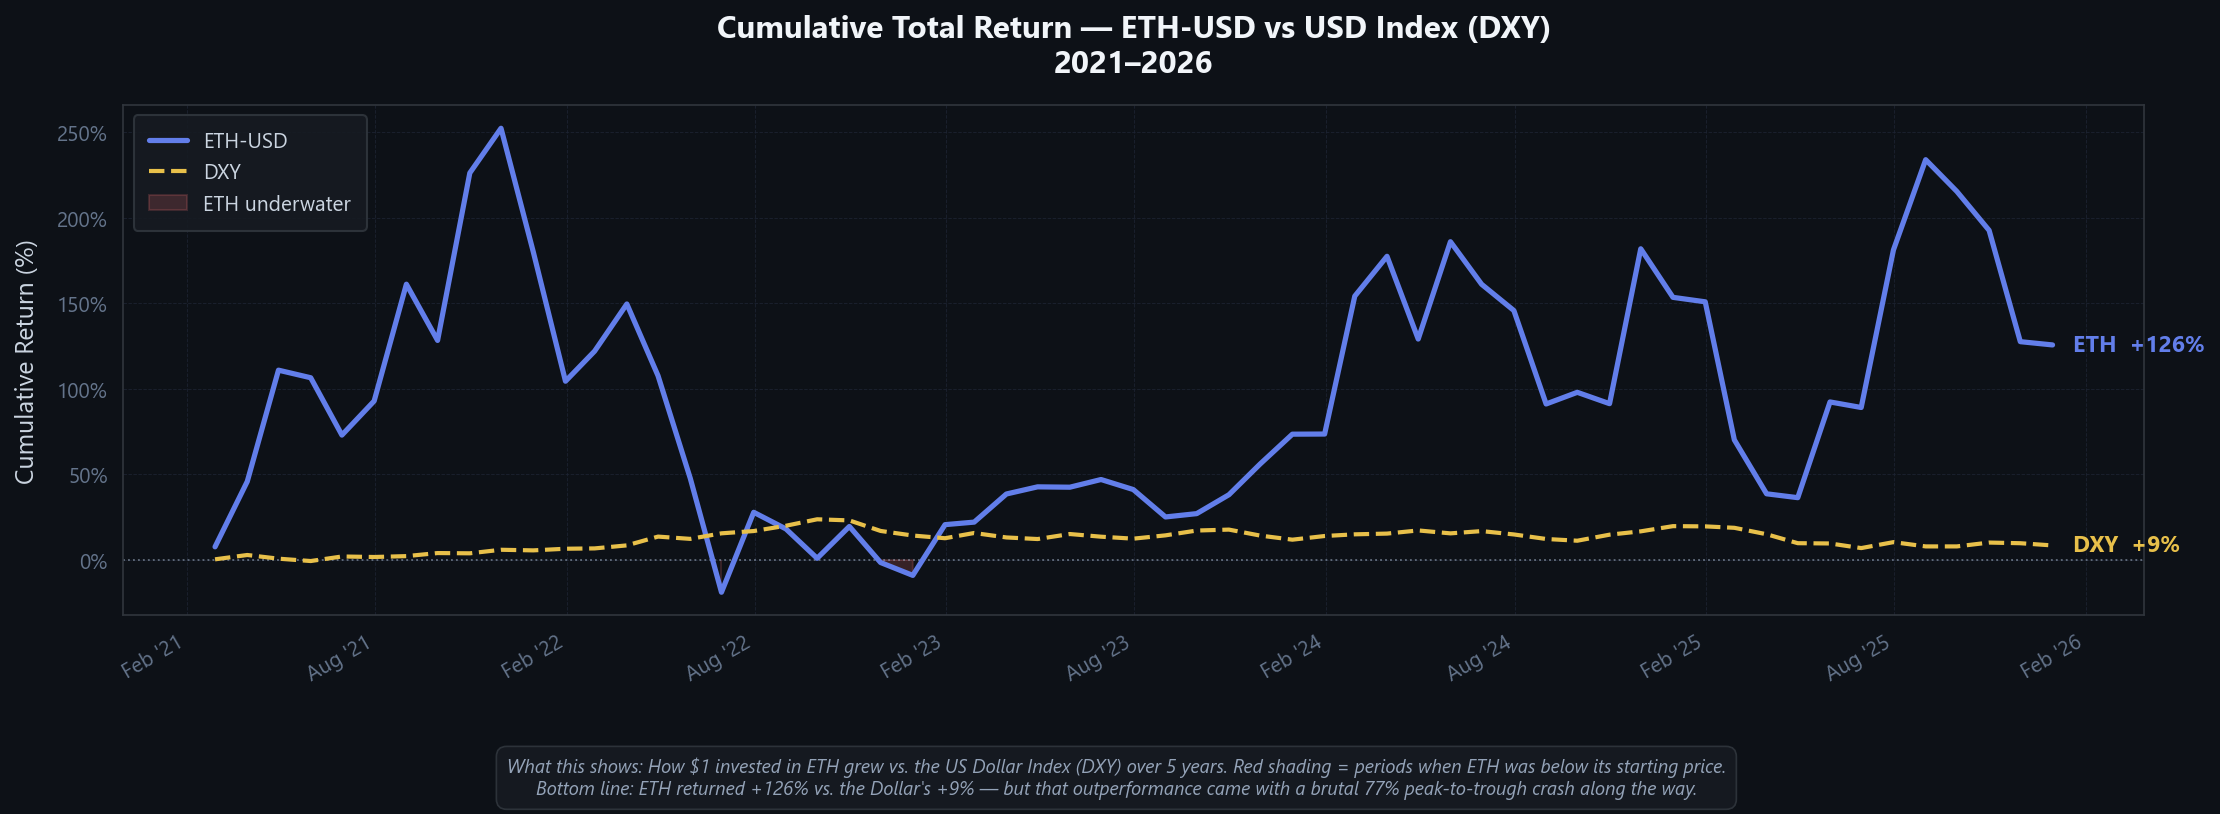

In [9]:
fig, ax = plt.subplots(figsize=(15, 5.5))

eth_cum = (1 + simple_returns[ETH_TICKER]).cumprod() - 1
dxy_cum = (1 + simple_returns[DXY_TICKER]).cumprod() - 1

ax.plot(eth_cum.index, eth_cum * 100, color=PALETTE["eth"], lw=2.5, label="ETH-USD", zorder=3)
ax.plot(dxy_cum.index, dxy_cum * 100, color=PALETTE["dxy"], lw=2.0, label="DXY", ls="--", zorder=3)
ax.axhline(0, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.6, zorder=2)

# Dual-layer fill: solid core + soft glow for ETH underwater periods
ax.fill_between(
    eth_cum.index, eth_cum * 100, 0,
    where=(eth_cum < 0),
    alpha=0.18, color=PALETTE["negative"], zorder=1, label="ETH underwater",
)

ax.set_title("Cumulative Total Return — ETH-USD vs USD Index (DXY)\n2021–2026")
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="upper left")

# Terminal value annotations
_ann_kw = dict(xytext=(10, 0), textcoords="offset points", va="center",
               fontsize=11, fontweight="bold")
for series, label, color in [
    (eth_cum, f"ETH  {eth_cum.iloc[-1]:+.0%}", PALETTE["eth"]),
    (dxy_cum, f"DXY  {dxy_cum.iloc[-1]:+.0%}", PALETTE["dxy"]),
]:
    ax.annotate(label, xy=(series.index[-1], series.iloc[-1] * 100),
                color=color, **_ann_kw)


_caption = (
    "What this shows: How $1 invested in ETH grew vs. the US Dollar Index (DXY) over 5 years. Red shading = periods when ETH was below its starting price.\n"
    "Bottom line: ETH returned +126% vs. the Dollar's +9% — but that outperformance came with a brutal 77% peak-to-trough crash along the way."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.savefig("01_cumulative_returns.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 2 — Monthly Return Heatmap

A calendar heat-map of ETH's monthly simple returns (green = gain, red = loss). Reading row-by-row reveals intra-year seasonality; reading column-by-column reveals which calendar months were consistently strong or weak across all five years.

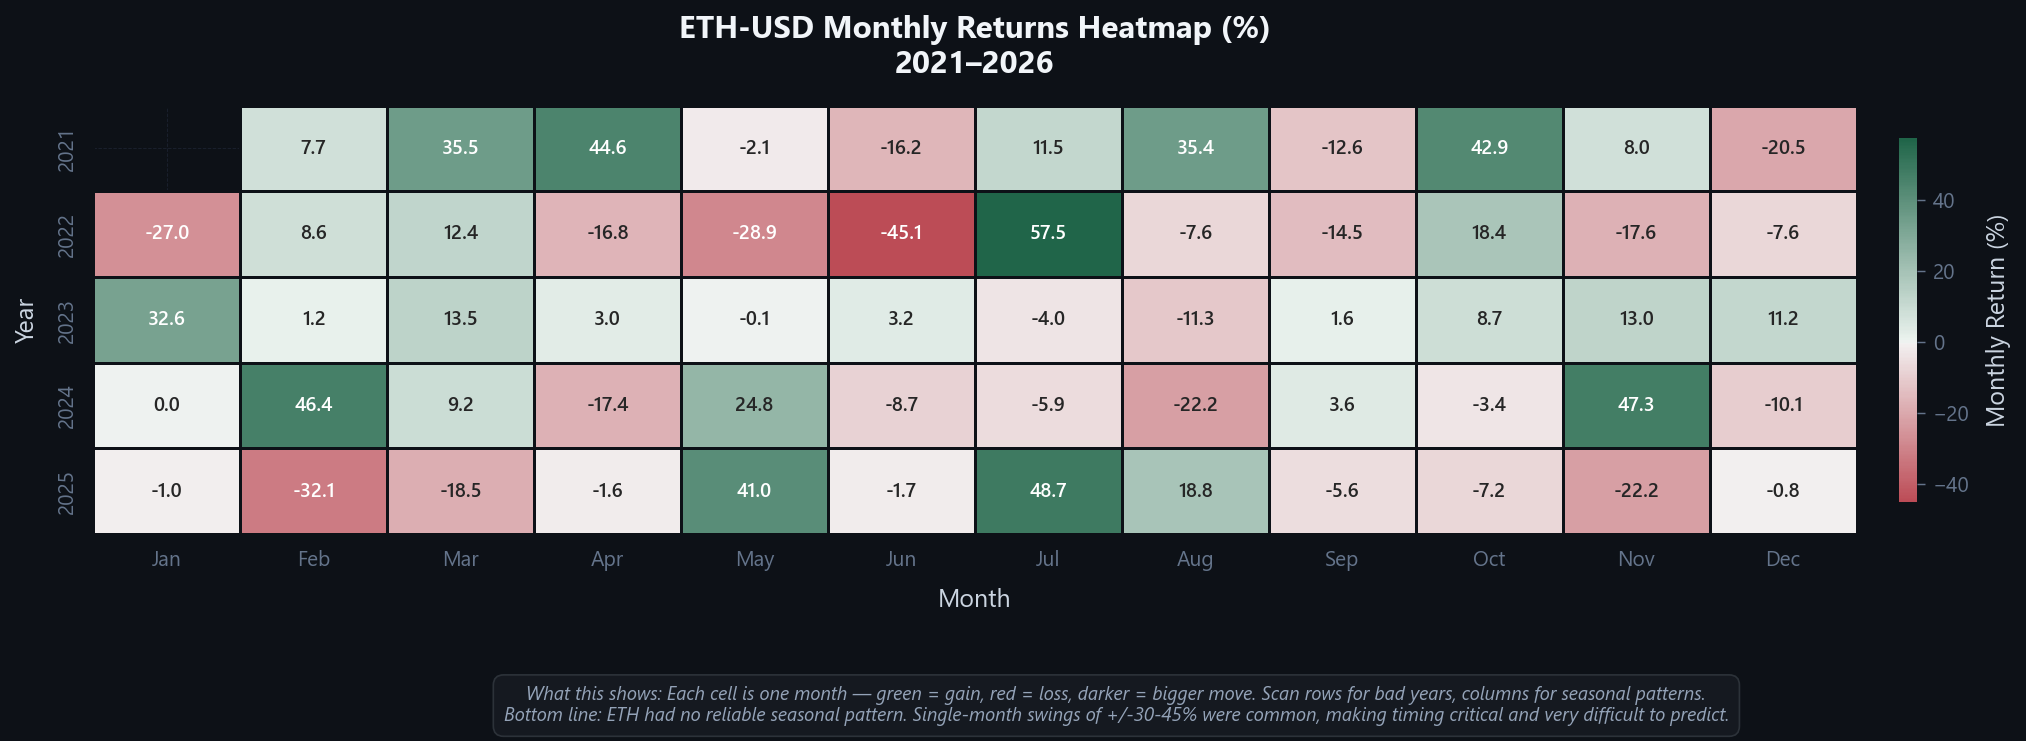

In [10]:
# Pivot ETH monthly returns into a (Year × Month) matrix
eth_pivot = simple_returns[ETH_TICKER].copy()
eth_pivot = eth_pivot.to_frame()
eth_pivot["Year"]  = eth_pivot.index.year
eth_pivot["Month"] = eth_pivot.index.month

heatmap_data = eth_pivot.pivot_table(
    values=ETH_TICKER, index="Year", columns="Month"
) * 100  # convert to percentage

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(15, 5))

sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    linewidths=0.5, linecolor="#0D1117",
    cmap=sns.diverging_palette(10, 150, s=85, l=38, as_cmap=True),
    center=0,
    ax=ax,
    annot_kws={"size": 9.5, "weight": "semibold"},
    cbar_kws={"label": "Monthly Return (%)", "shrink": 0.85, "pad": 0.02},
    xticklabels=month_labels,
)

ax.set_title("ETH-USD Monthly Returns Heatmap (%)\n2021–2026")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.tick_params(left=False, bottom=False)


_caption = (
    "What this shows: Each cell is one month — green = gain, red = loss, darker = bigger move. Scan rows for bad years, columns for seasonal patterns.\n"
    "Bottom line: ETH had no reliable seasonal pattern. Single-month swings of +/-30-45% were common, making timing critical and very difficult to predict."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.savefig("02_monthly_heatmap.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 3 — Annual Returns Bar Chart

Side-by-side geometric CAGR bars for ETH and DXY, year-by-year. Loss years are coloured red. Labels above each bar show the exact annual figure, making it easy to spot which years dominated the 5-year CAGR and which years destroyed capital.

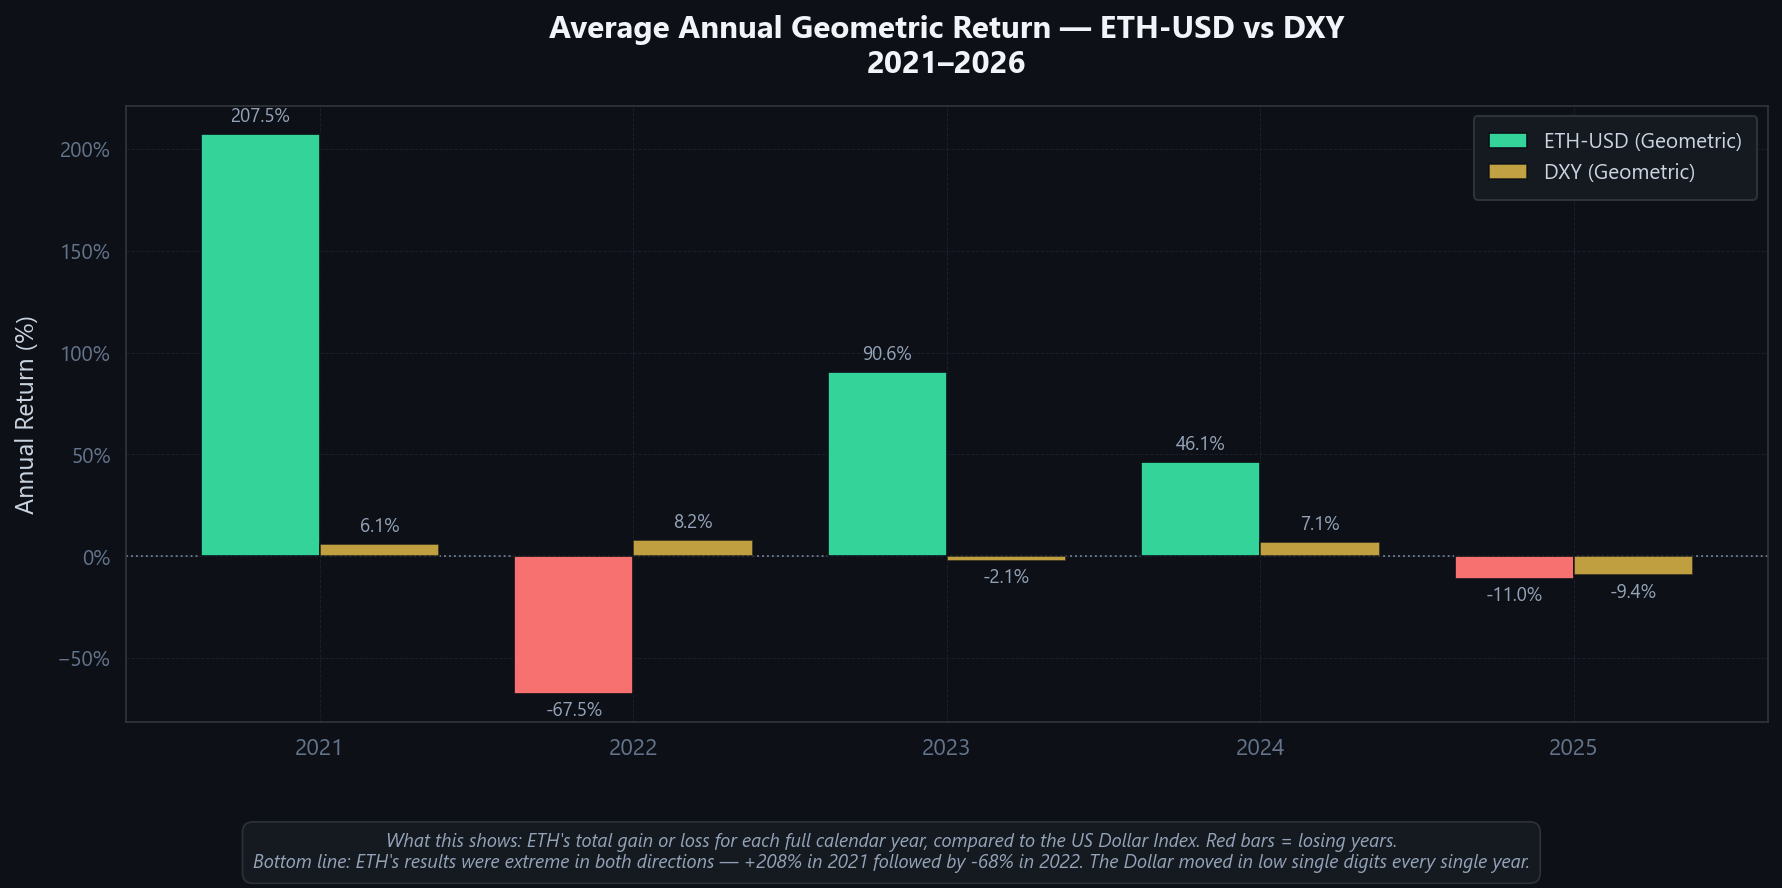

In [11]:
eth_annual_geo = annual_returns["ETH-USD_geo"] * 100
dxy_annual_geo = annual_returns["DX-Y.NYB_geo"] * 100
years = eth_annual_geo.index.astype(str)
x = np.arange(len(years))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars_eth = ax.bar(
    x - width / 2, eth_annual_geo,
    width=width, label="ETH-USD (Geometric)",
    color=[PALETTE["positive"] if v >= 0 else PALETTE["negative"] for v in eth_annual_geo],
    edgecolor="#0D1117", linewidth=0.8, zorder=3,
)
bars_dxy = ax.bar(
    x + width / 2, dxy_annual_geo,
    width=width, label="DXY (Geometric)",
    color=PALETTE["dxy"], alpha=0.82,
    edgecolor="#0D1117", linewidth=0.8, zorder=3,
)

ax.axhline(0, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.7, zorder=2)
ax.bar_label(bars_eth, fmt="%.1f%%", padding=4, fontsize=9, color=PALETTE["neutral"])
ax.bar_label(bars_dxy, fmt="%.1f%%", padding=4, fontsize=9, color=PALETTE["neutral"])

ax.set_title("Average Annual Geometric Return — ETH-USD vs DXY\n2021–2026")
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel("Annual Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend()


_caption = (
    "What this shows: ETH's total gain or loss for each full calendar year, compared to the US Dollar Index. Red bars = losing years.\n"
    "Bottom line: ETH's results were extreme in both directions — +208% in 2021 followed by -68% in 2022. The Dollar moved in low single digits every single year."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("03_annual_returns.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 4 — Rolling Volatility & Sharpe Ratio

Two stacked panels sharing a common time axis. **Top:** 12-month rolling annualised volatility — reveals whether ETH was entering or exiting high-risk regimes. **Bottom:** 12-month rolling Sharpe ratio — green fill indicates periods the risk-adjusted return was positive, red where it was negative. Sustained red fill overlapping high volatility marks the peak of bear markets.

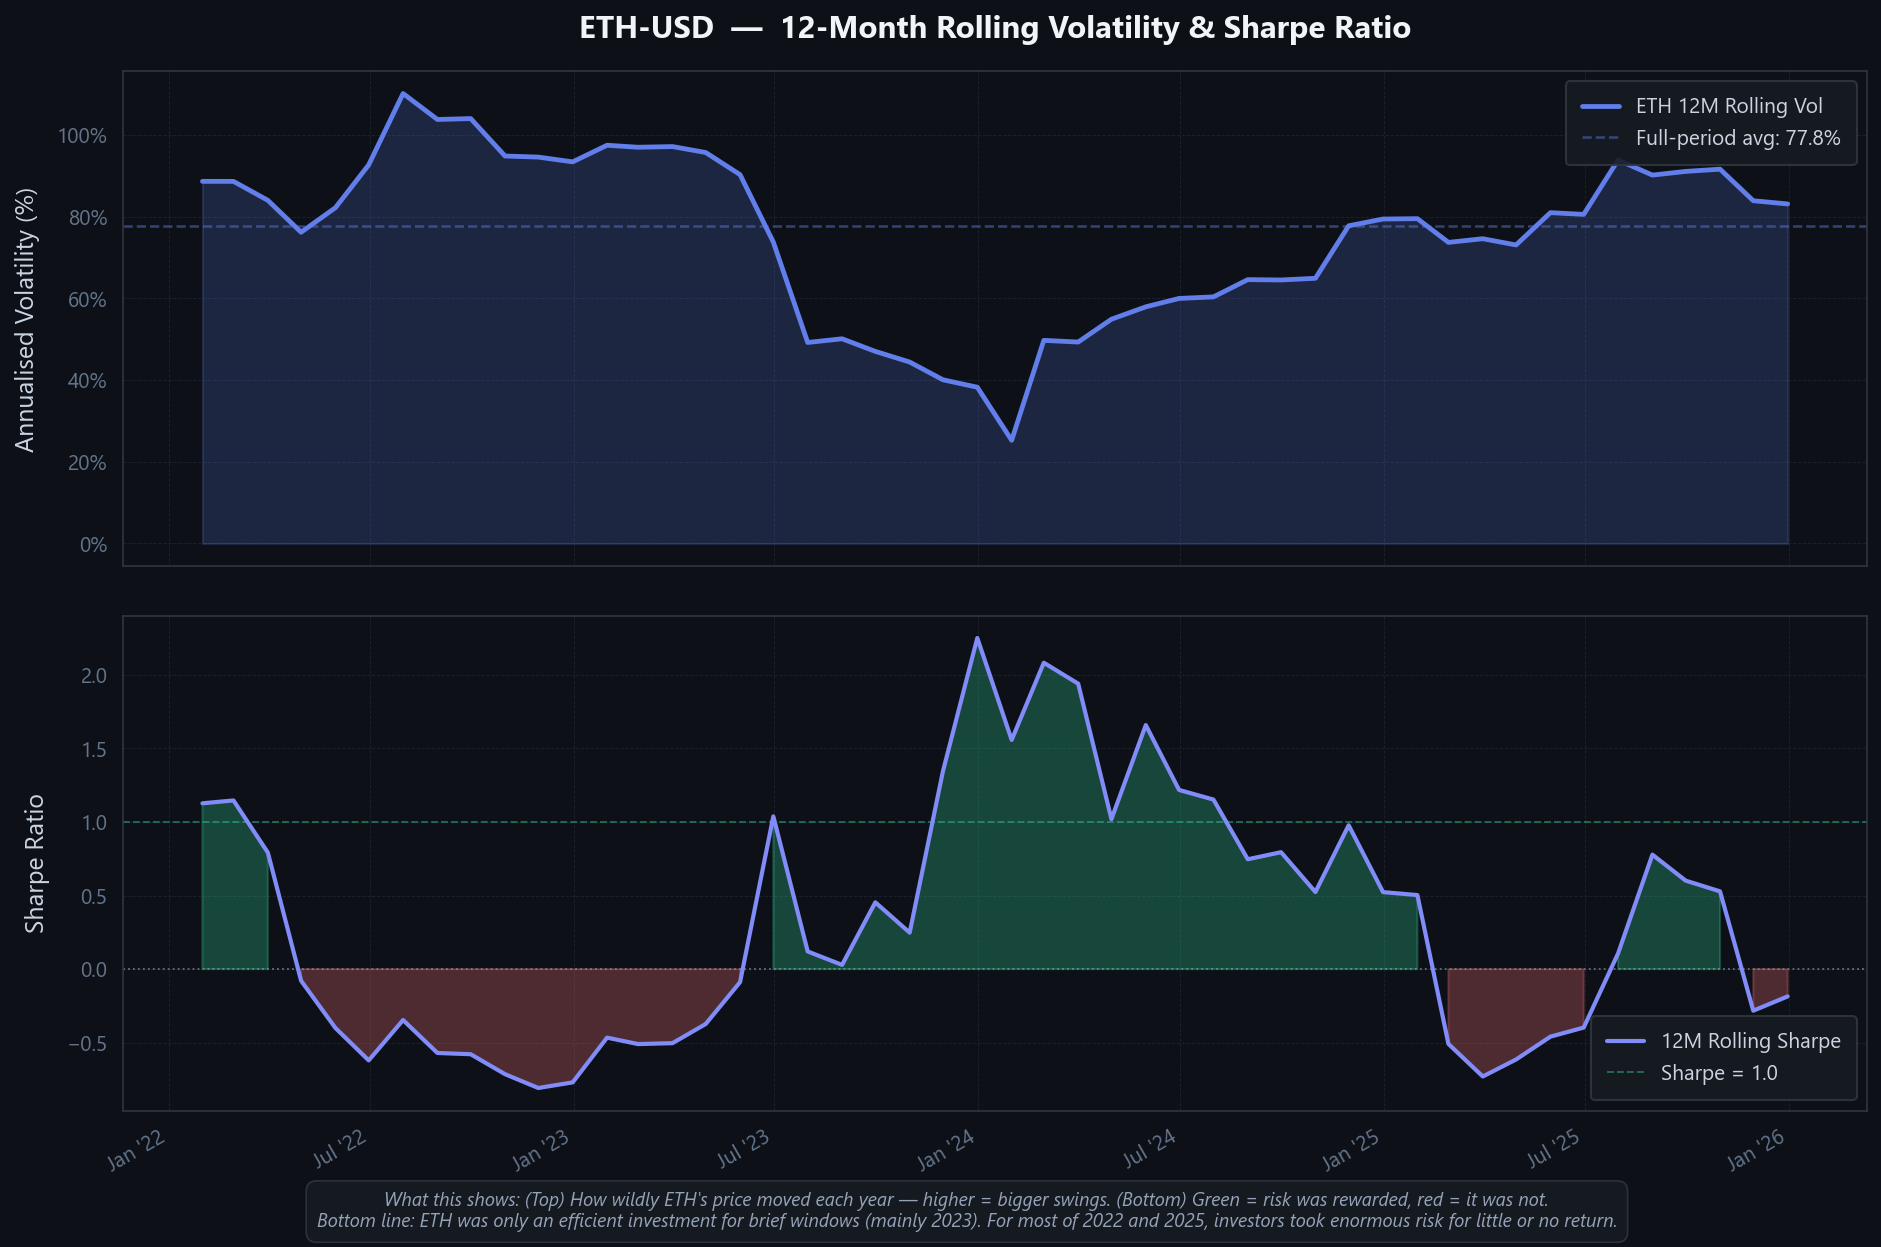

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                          gridspec_kw={"hspace": 0.10, "height_ratios": [1, 1]})

# ── Top panel: rolling volatility ─────────────────────────────────────────────
ax1 = axes[0]
rv = eth_metrics["rolling_vol"] * 100
ax1.plot(rv.index, rv, color=PALETTE["eth"], lw=2.3,
         label=f"ETH {ROLLING_WINDOW}M Rolling Vol", zorder=3)
ax1.fill_between(rv.index, rv, alpha=0.20, color=PALETTE["eth"], zorder=2)
ax1.axhline(
    eth_metrics["vol_annual"] * 100, color=PALETTE["eth"],
    lw=1.2, ls="--", alpha=0.45,
    label=f"Full-period avg: {eth_metrics['vol_annual']:.1%}",
)
ax1.set_ylabel("Annualised Volatility (%)")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax1.legend(loc="upper right")
ax1.set_title(f"ETH-USD  —  {ROLLING_WINDOW}-Month Rolling Volatility & Sharpe Ratio")
ax1.spines["bottom"].set_color(_EDGE)

# ── Bottom panel: rolling Sharpe ──────────────────────────────────────────────
ax2 = axes[1]
rs = eth_metrics["rolling_sharpe"].dropna()

ax2.fill_between(rs.index, rs, 0, where=(rs >= 0), alpha=0.28, color=PALETTE["positive"], zorder=2)
ax2.fill_between(rs.index, rs, 0, where=(rs <  0), alpha=0.28, color=PALETTE["negative"], zorder=2)
ax2.plot(rs.index, rs, color=PALETTE["highlight"], lw=2.0,
         label=f"{ROLLING_WINDOW}M Rolling Sharpe", zorder=3)
ax2.axhline(0, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.6, zorder=2)
ax2.axhline(1, color=PALETTE["positive"], lw=0.9, ls="--", alpha=0.45, label="Sharpe = 1.0")

ax2.set_ylabel("Sharpe Ratio")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.legend(loc="lower right")


_caption = (
    "What this shows: (Top) How wildly ETH's price moved each year — higher = bigger swings. (Bottom) Green = risk was rewarded, red = it was not.\n"
    "Bottom line: ETH was only an efficient investment for brief windows (mainly 2023). For most of 2022 and 2025, investors took enormous risk for little or no return."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.savefig("04_rolling_vol_sharpe.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 5 — Drawdown Underwater Chart

Depicts how far ETH was trading below its previous all-time peak at each point in time. Zero = at or above the prior peak; negative values show the percentage of capital still "underwater." The maximum drawdown date and depth are annotated with an arrow.

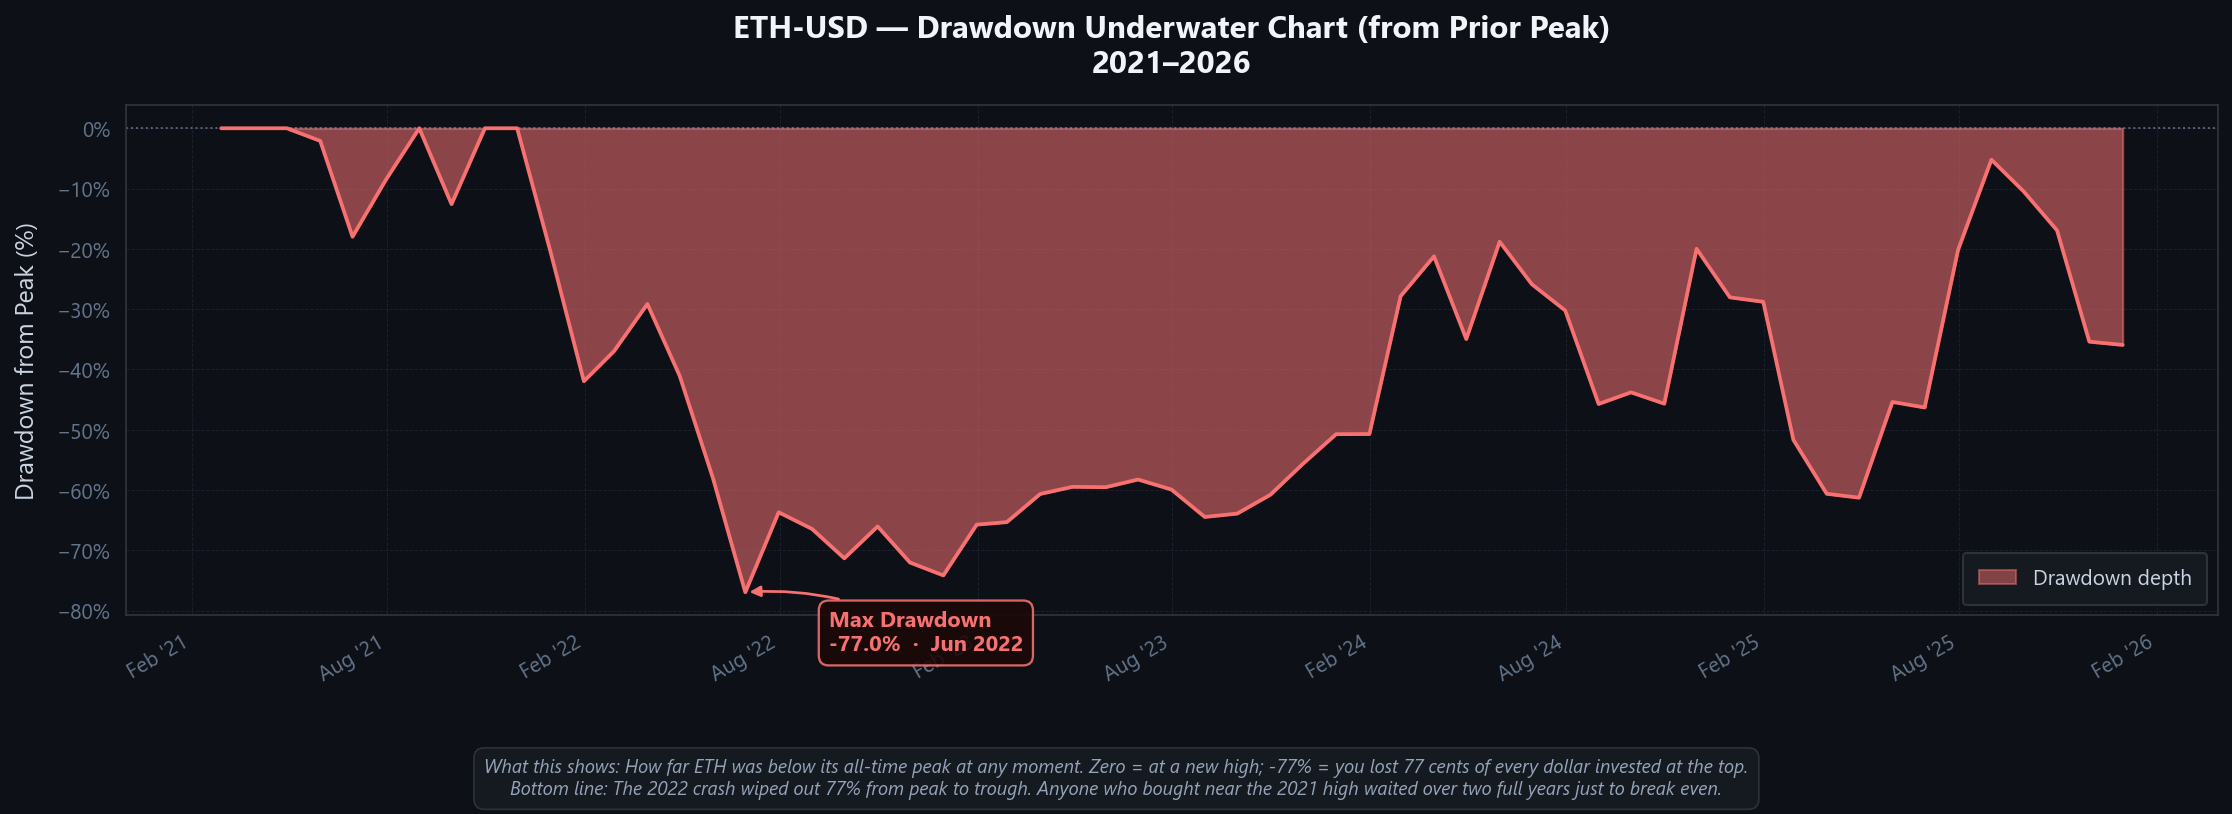

In [13]:
fig, ax = plt.subplots(figsize=(15, 5.5))

dd = eth_metrics["drawdown_series"] * 100

# Dual-layer fill: strong core + soft glow
ax.fill_between(dd.index, dd, 0, alpha=0.48, color=PALETTE["negative"], zorder=2, label="Drawdown depth")
ax.fill_between(dd.index, dd, 0, alpha=0.12, color=PALETTE["negative"], zorder=1)
ax.plot(dd.index, dd, color=PALETTE["negative"], lw=1.8, zorder=3)
ax.axhline(0, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.6, zorder=2)

# Maximum drawdown annotation
mdd_date = dd.idxmin()
mdd_val  = dd.min()
ax.annotate(
    f"Max Drawdown\n{mdd_val:.1f}%  ·  {mdd_date.strftime('%b %Y')}",
    xy=(mdd_date, mdd_val),
    xytext=(40, -28), textcoords="offset points",
    color=PALETTE["negative"], fontsize=10.5, fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color=PALETTE["negative"], lw=1.3,
                    connectionstyle="arc3,rad=0.15"),
    bbox=dict(boxstyle="round,pad=0.45", fc="#1C0808", ec=PALETTE["negative"],
              lw=1.1, alpha=0.88),
)

ax.set_title("ETH-USD — Drawdown Underwater Chart (from Prior Peak)\n2021–2026")
ax.set_ylabel("Drawdown from Peak (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="lower right")


_caption = (
    "What this shows: How far ETH was below its all-time peak at any moment. Zero = at a new high; -77% = you lost 77 cents of every dollar invested at the top.\n"
    "Bottom line: The 2022 crash wiped out 77% from peak to trough. Anyone who bought near the 2021 high waited over two full years just to break even."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.13, 1, 1])
plt.savefig("05_drawdown.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 6 — ETH / DXY Correlation Dashboard

A four-panel summary of the ETH–DXY statistical relationship:

| Panel | Content |
|-------|---------|
| Top-left | Scatter plot of monthly returns + OLS regression line |
| Top-right | 12-month rolling Pearson ρ with full-period average reference |
| Bottom-left | ETH monthly return distribution vs Normal reference curve |
| Bottom-right | Statistical summary (ρ, 95% CI, t-stat, p-value, β, α, R²) |

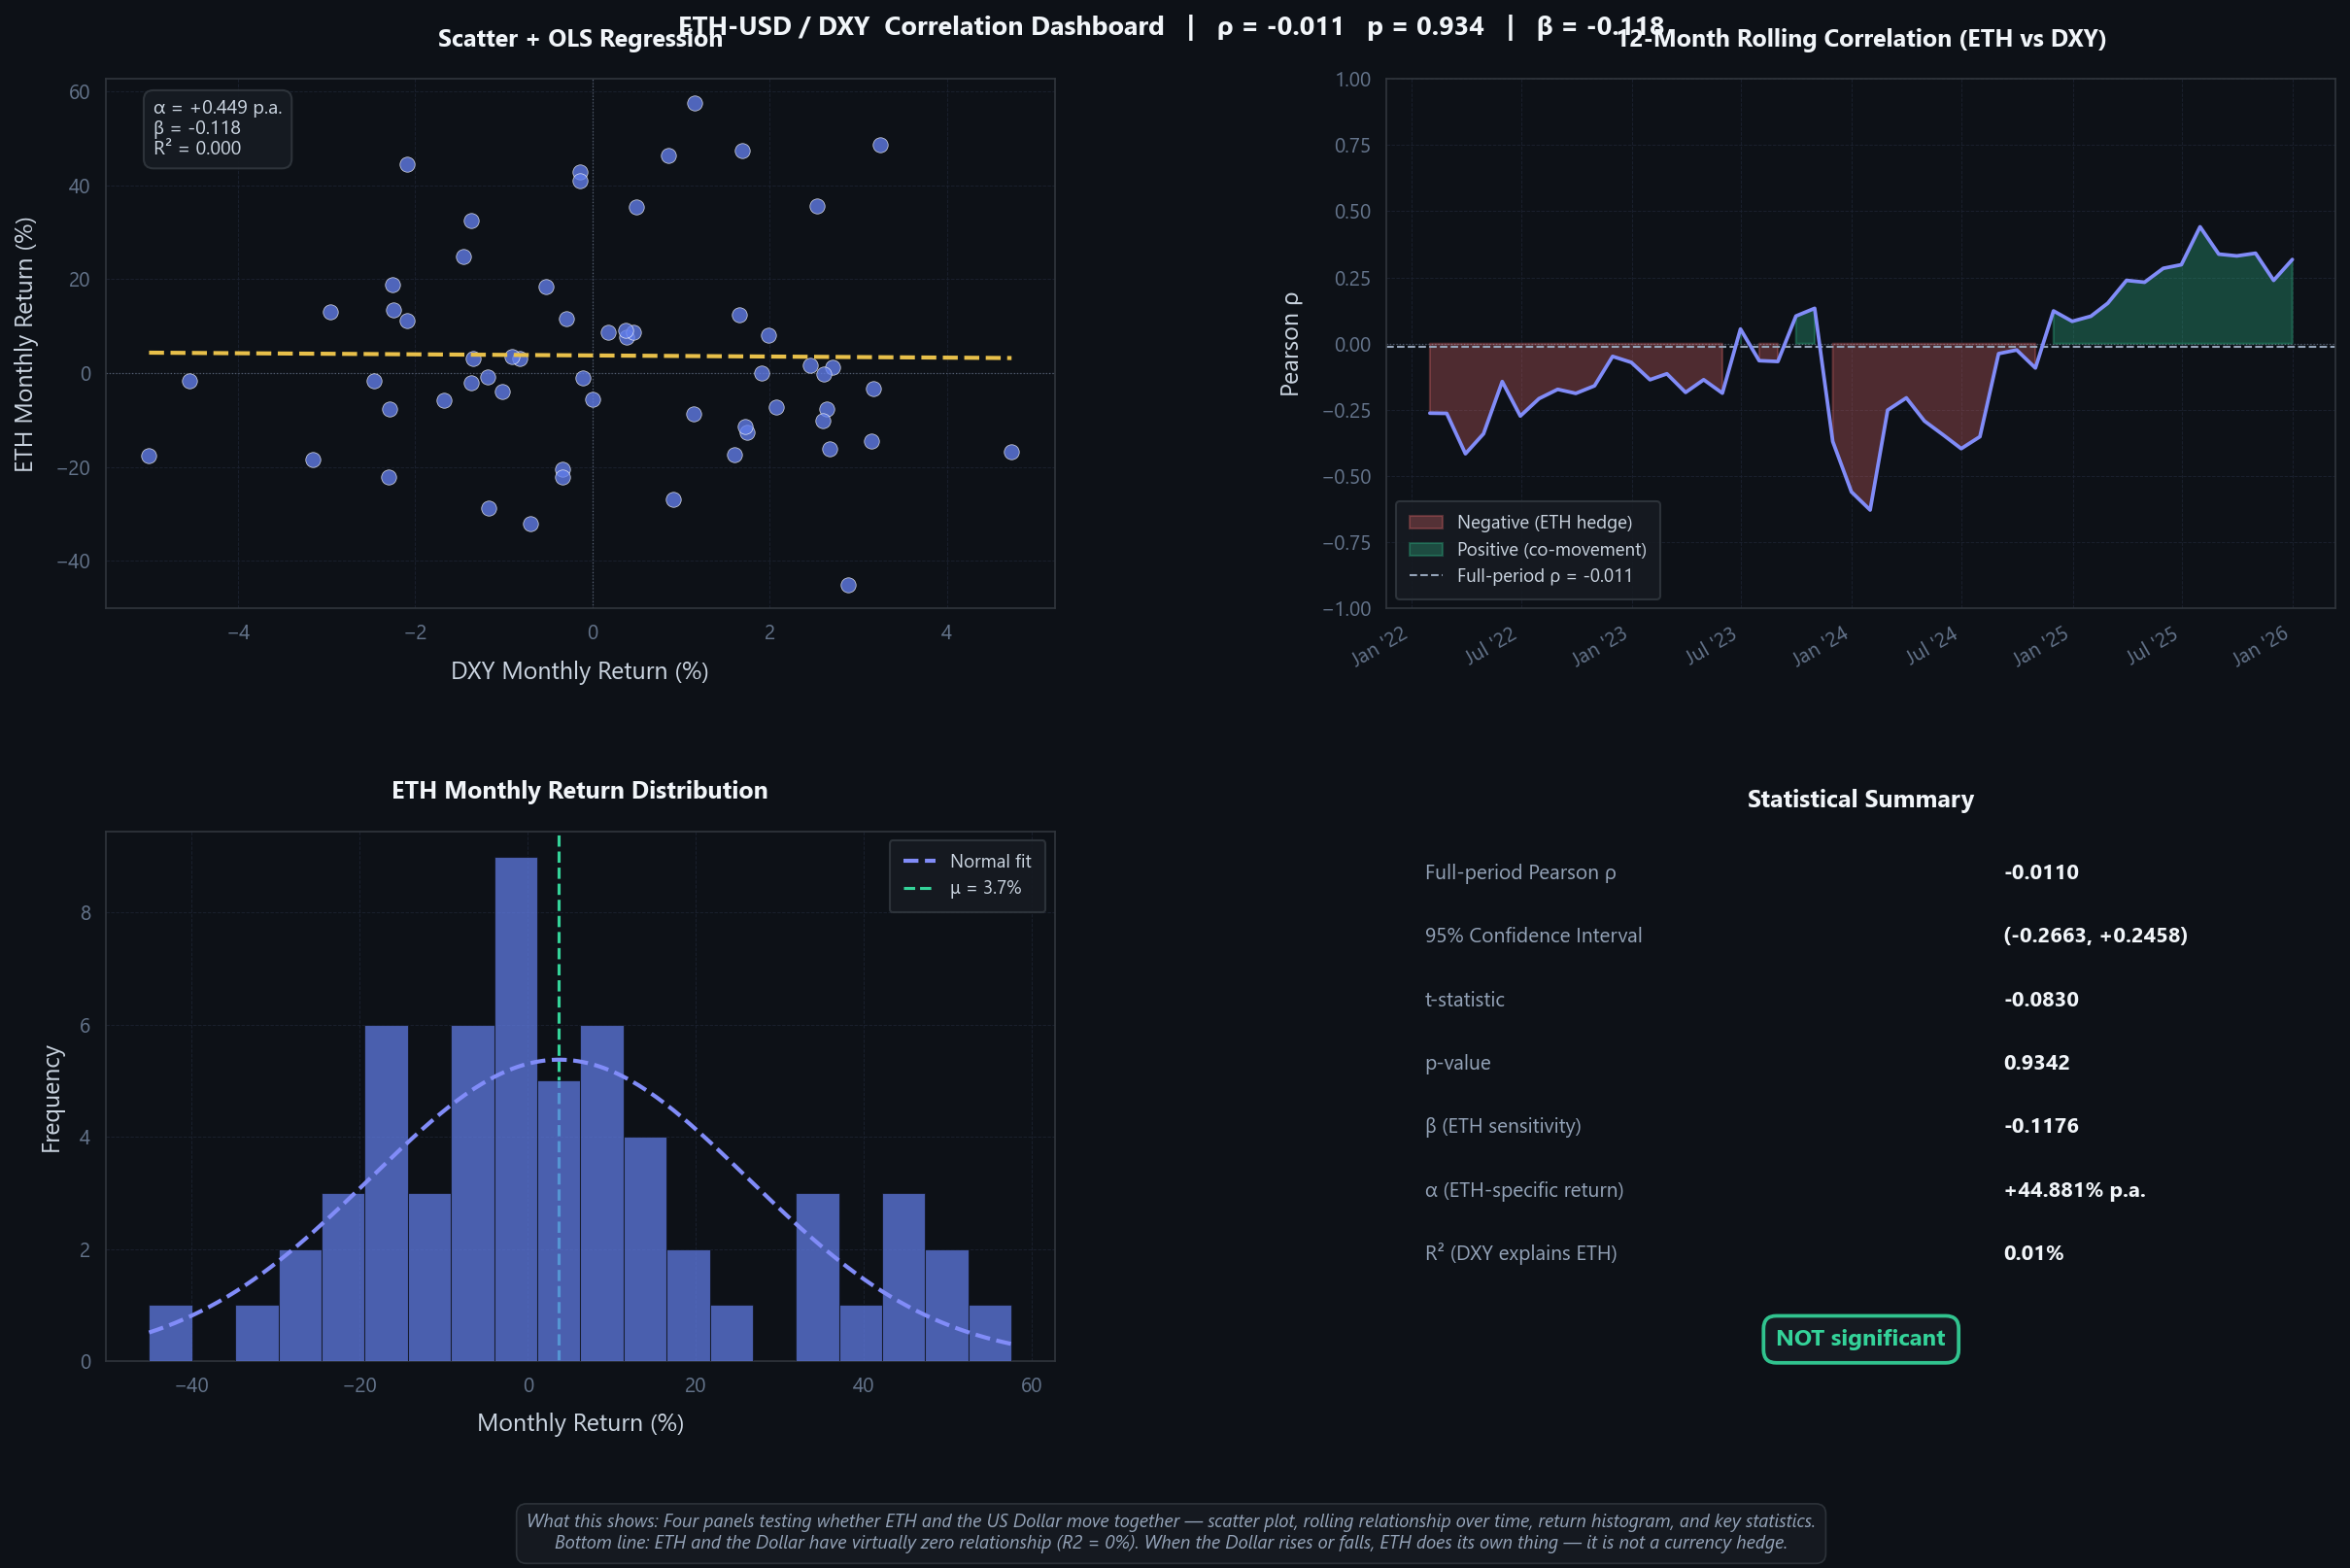

In [14]:
aligned = corr_results["aligned"]
e_col, d_col = aligned.columns[0], aligned.columns[1]

fig = plt.figure(figsize=(17, 11), facecolor="#0D1117")
fig.suptitle(
    f"ETH-USD / DXY  Correlation Dashboard   |   ρ = {corr_results['pearson_r']:+.3f}   "
    f"p = {corr_results['p_value']:.3f}   |   β = {corr_results['beta']:+.3f}",
    fontsize=13, fontweight="bold", y=0.98, color="#F1F5F9",
)

gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.35,
                       left=0.07, right=0.97, top=0.94, bottom=0.14)

# ── Panel A: scatter + OLS regression line ────────────────────────────────────
ax_scatter = fig.add_subplot(gs[0, 0])
ax_scatter.scatter(
    aligned[d_col] * 100, aligned[e_col] * 100,
    color=PALETTE["eth"], alpha=0.78, s=55, zorder=3,
    edgecolors="#FFFFFF", linewidths=0.35,
)
x_fit = np.linspace(aligned[d_col].min(), aligned[d_col].max(), 100)
y_fit = corr_results["beta"] * x_fit + corr_results["alpha"]
ax_scatter.plot(x_fit * 100, y_fit * 100, color=PALETTE["dxy"], lw=2.0, ls="--", zorder=4)
ax_scatter.axhline(0, color=PALETTE["neutral"], lw=0.6, ls=":", alpha=0.5)
ax_scatter.axvline(0, color=PALETTE["neutral"], lw=0.6, ls=":", alpha=0.5)
ax_scatter.set_xlabel("DXY Monthly Return (%)")
ax_scatter.set_ylabel("ETH Monthly Return (%)")
ax_scatter.set_title("Scatter + OLS Regression", fontsize=12, fontweight="bold", color="#F1F5F9")
ax_scatter.text(
    0.05, 0.96,
    f"α = {corr_results['alpha']*12:+.3f} p.a.\nβ = {corr_results['beta']:+.3f}\nR² = {corr_results['r_squared']:.3f}",
    transform=ax_scatter.transAxes, va="top", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", fc="#161B22", ec="#30363D", alpha=0.92),
)

# ── Panel B: rolling correlation ──────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[0, 1])
rc = corr_results["rolling_corr"].dropna()
ax_roll.fill_between(rc.index, rc, 0,
    where=(rc < 0),  alpha=0.28, color=PALETTE["negative"], label="Negative (ETH hedge)")
ax_roll.fill_between(rc.index, rc, 0,
    where=(rc >= 0), alpha=0.28, color=PALETTE["positive"], label="Positive (co-movement)")
ax_roll.plot(rc.index, rc, color=PALETTE["highlight"], lw=1.8, zorder=3)
ax_roll.axhline(corr_results["pearson_r"], color=PALETTE["neutral"], lw=1.0, ls="--",
                label=f"Full-period ρ = {corr_results['pearson_r']:+.3f}")
ax_roll.axhline(0, color=PALETTE["neutral"], lw=0.6, ls=":", alpha=0.5)
ax_roll.set_ylim(-1, 1)
ax_roll.set_title(f"{ROLLING_WINDOW}-Month Rolling Correlation (ETH vs DXY)",
                  fontsize=12, fontweight="bold", color="#F1F5F9")
ax_roll.set_ylabel("Pearson ρ")
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax_roll.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax_roll.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax_roll.legend(fontsize=9, loc="lower left")

# ── Panel C: ETH return distribution ──────────────────────────────────────────
ax_dist = fig.add_subplot(gs[1, 0])
eth_r = aligned[e_col] * 100
ax_dist.hist(eth_r, bins=20, color=PALETTE["eth"], alpha=0.72,
             edgecolor="#0D1117", linewidth=0.5, zorder=3)
mu, sigma_d = eth_r.mean(), eth_r.std()
x_norm = np.linspace(eth_r.min(), eth_r.max(), 200)
from scipy.stats import norm
ax_dist.plot(
    x_norm,
    norm.pdf(x_norm, mu, sigma_d) * len(eth_r) * (eth_r.max() - eth_r.min()) / 20,
    color=PALETTE["highlight"], lw=2.0, ls="--", label="Normal fit", zorder=4,
)
ax_dist.axvline(mu, color=PALETTE["positive"], lw=1.5, ls="--", label=f"μ = {mu:.1f}%")
ax_dist.set_title("ETH Monthly Return Distribution",
                  fontsize=12, fontweight="bold", color="#F1F5F9")
ax_dist.set_xlabel("Monthly Return (%)")
ax_dist.set_ylabel("Frequency")
ax_dist.legend(fontsize=9)

# ── Panel D: statistical summary ──────────────────────────────────────────────
ax_info = fig.add_subplot(gs[1, 1])
ax_info.axis("off")

is_sig = corr_results["p_value"] < 0.05
sig_color = PALETTE["negative"] if is_sig else PALETTE["positive"]
sig_label = "SIGNIFICANT\nnegative correlation" if (is_sig and corr_results["pearson_r"] < 0) else "NOT significant"

info_lines = [
    ("Full-period Pearson ρ",    f"{corr_results['pearson_r']:+.4f}"),
    ("95% Confidence Interval",  f"({corr_results['ci_95'][0]:+.4f}, {corr_results['ci_95'][1]:+.4f})"),
    ("t-statistic",              f"{corr_results['t_stat']:+.4f}"),
    ("p-value",                  f"{corr_results['p_value']:.4f}"),
    ("β (ETH sensitivity)",      f"{corr_results['beta']:+.4f}"),
    ("α (ETH-specific return)",  f"{corr_results['alpha']*12:+.3%} p.a."),
    ("R² (DXY explains ETH)",    f"{corr_results['r_squared']:.2%}"),
]

for i, (label, val) in enumerate(info_lines):
    ax_info.text(0.04, 0.91 - i * 0.12, label, transform=ax_info.transAxes,
                 fontsize=10, color=PALETTE["neutral"])
    ax_info.text(0.65, 0.91 - i * 0.12, val, transform=ax_info.transAxes,
                 fontsize=10.5, color="#F1F5F9", fontweight="bold")

ax_info.text(0.5, 0.03, sig_label, transform=ax_info.transAxes,
             ha="center", fontsize=11.5, color=sig_color, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec=sig_color,
                       lw=1.8, alpha=0.92))
ax_info.set_title("Statistical Summary", fontsize=12, fontweight="bold",
                  color="#F1F5F9", pad=12)


_caption = (
    "What this shows: Four panels testing whether ETH and the US Dollar move together — scatter plot, rolling relationship over time, return histogram, and key statistics.\n"
    "Bottom line: ETH and the Dollar have virtually zero relationship (R2 = 0%). When the Dollar rises or falls, ETH does its own thing — it is not a currency hedge."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.savefig("06_correlation_dashboard.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

---

## Part II — Multi-Asset Comparative Analysis: ETH vs BTC vs NASDAQ-100

### Objective
Benchmark Ethereum's risk-adjusted performance against three reference assets:

| Asset | Ticker | Why it matters |
|-------|--------|---------------|
| **Bitcoin** | `BTC-USD` | The dominant crypto — natural peer comparison for ETH |
| **NASDAQ-100** | `^NDX` | High-growth tech equity — tests whether ETH's vol premium is justified vs equities |
| **DXY** | `DX-Y.NYB` | Retained from Part I as the USD-strength macro backdrop |

### New Visualisations

| Plot | Question answered |
|------|-------------------|
| 7. Normalized cumulative returns | How did $100 invested in each asset grow over 5 years? |
| 8. Annual returns comparison | Were crypto gains driven by the same years as tech equities? |
| 9. Risk-return scatter | Where does each asset sit on the volatility–reward curve? |
| 10. Multi-asset drawdown | How did bear-market depth and duration compare? |
| 11. Pairwise correlation heatmap | How tightly do the four assets co-move? |
| 12. Rolling correlations | Has ETH's relationship with BTC and NASDAQ-100 changed over time? |
| 13. Performance metrics table | Side-by-side summary of all key quantitative measures. |

### Data Preparation — Fetching BTC & NASDAQ-100

Extend the colour palette with Bitcoin orange and NASDAQ cyan, then fetch BTC-USD and `^NDX` daily prices using the same `fetch_price_series()` function defined in Part I. A new generic helper, `build_multi_asset_prices()`, aligns all four assets onto a common month-end calendar to produce `all_prices` and `all_returns`.

In [15]:
# ── Additional Tickers for Comparative Analysis ───────────────────────────────
BTC_TICKER:    str = "BTC-USD"
NASDAQ_TICKER: str = "^NDX"     # NASDAQ-100 Index (tech-equity benchmark)

PALETTE.update({
    "btc":    "#F7931A",  # Bitcoin brand orange
    "nasdaq": "#00B4D8",  # NASDAQ cyan-blue
})

log.info("Fetching comparative assets: BTC=%s | NASDAQ=%s", BTC_TICKER, NASDAQ_TICKER)
btc_daily    = fetch_price_series(BTC_TICKER,    START_DATE, END_DATE)
nasdaq_daily = fetch_price_series(NASDAQ_TICKER, START_DATE, END_DATE)

02:24:57  INFO      Fetching comparative assets: BTC=BTC-USD | NASDAQ=^NDX
02:24:57  INFO      Fetching BTC-USD    from 2021-01-01 to 2026-01-01 ...
02:24:58  INFO        ✓ BTC-USD | 1826 daily bars | 29374.15 → 87508.83 | NaN count: 0
02:24:58  INFO      Fetching ^NDX       from 2021-01-01 to 2026-01-01 ...
02:24:58  INFO        ✓ ^NDX | 1255 daily bars | 12694.66 → 25249.85 | NaN count: 0


In [16]:
# ── Multi-Asset Price Matrix & Returns ────────────────────────────────────────
def build_multi_asset_prices(*daily_series: pd.Series) -> pd.DataFrame:
    """
    Resample any number of daily price series to month-end and align them
    on a common index.  Forward-fills up to 1 period for exchange-holiday gaps.
    """
    monthly = [s.resample("ME").last() for s in daily_series]
    prices  = pd.concat(monthly, axis=1)
    prices.ffill(limit=1, inplace=True)
    prices.dropna(inplace=True)
    log.info("Multi-asset price matrix: %d months × %d assets", *prices.shape)
    return prices


# ETH, BTC, DXY, NASDAQ-100 — aligned on a common month-end calendar
all_prices  = build_multi_asset_prices(eth_daily, btc_daily, dxy_daily, nasdaq_daily)
all_returns = all_prices.pct_change().dropna()

print("\n── Multi-Asset Monthly Prices (last 3 rows) ──")
print(all_prices.tail(3).round(2).to_string())
print(f"\nShape  : {all_prices.shape}")
print(f"Period : {all_prices.index[0].date()} → {all_prices.index[-1].date()}")

02:24:58  INFO      Multi-asset price matrix: 60 months × 4 assets



── Multi-Asset Monthly Prices (last 3 rows) ──
            ETH-USD    BTC-USD  DX-Y.NYB      ^NDX
Date                                              
2025-10-31  3847.08  109556.16     99.80  25858.13
2025-11-30  2992.11   90394.31     99.46  25434.89
2025-12-31  2967.04   87508.83     98.28  25249.85

Shape  : (60, 4)
Period : 2021-01-31 → 2025-12-31


### Risk-Adjusted Metrics — All Four Assets

Run the full `compute_risk_metrics()` pipeline on every column of `all_returns`. Results are stored in `all_metrics` — a dict keyed by ticker symbol — so any subsequent cell can retrieve CAGR, Sharpe, drawdown series, etc. by name without recomputation.

In [17]:
# ── Risk Metrics — All Four Assets ────────────────────────────────────────────
ASSET_LABELS = {
    ETH_TICKER:    "ETH",
    BTC_TICKER:    "BTC",
    DXY_TICKER:    "DXY",
    NASDAQ_TICKER: "NASDAQ-100",
}

all_metrics = {
    ticker: compute_risk_metrics(all_returns[ticker])
    for ticker in all_returns.columns
}

metric_rows = [
    ("CAGR (Geometric)", "cagr",         True),
    ("Ann. Volatility",  "vol_annual",   True),
    ("Sharpe Ratio",     "sharpe",       False),
    ("Sortino Ratio",    "sortino",      False),
    ("Max Drawdown",     "max_drawdown", True),
    ("Calmar Ratio",     "calmar",       False),
]

col_w  = 14
header = f"{'Metric':<22}" + "".join(f"{ASSET_LABELS[t]:>{col_w}}" for t in all_returns.columns)
print(f"\n── Multi-Asset Risk-Adjusted Performance ──\n{header}")
print("─" * (22 + col_w * len(all_returns.columns)))
for disp, key, is_pct in metric_rows:
    fmt  = "{:.1%}" if is_pct else "{:.3f}"
    vals = "".join(f"{fmt.format(all_metrics[t][key]):>{col_w}}" for t in all_returns.columns)
    print(f"{disp:<22}{vals}")


── Multi-Asset Risk-Adjusted Performance ──
Metric                           ETH           BTC           DXY    NASDAQ-100
──────────────────────────────────────────────────────────────────────────────
CAGR (Geometric)               18.0%         21.9%          1.7%         14.6%
Ann. Volatility                77.8%         60.7%          7.3%         19.4%
Sharpe Ratio                   0.173         0.286        -0.389         0.520
Sortino Ratio                  0.232         0.343        -0.370         0.478
Max Drawdown                  -77.0%        -73.0%        -13.6%        -33.0%
Calmar Ratio                   0.234         0.299         0.123         0.443


### Plot 7 — Normalized Cumulative Returns

All four assets rebased to **100 at January 2021**, removing price-level differences (e.g. ETH at ~$730 vs NASDAQ at ~15 000) and expressing everything as pure percentage gain or loss from a common starting point. Terminal index values and net percentage changes are annotated on the right edge.

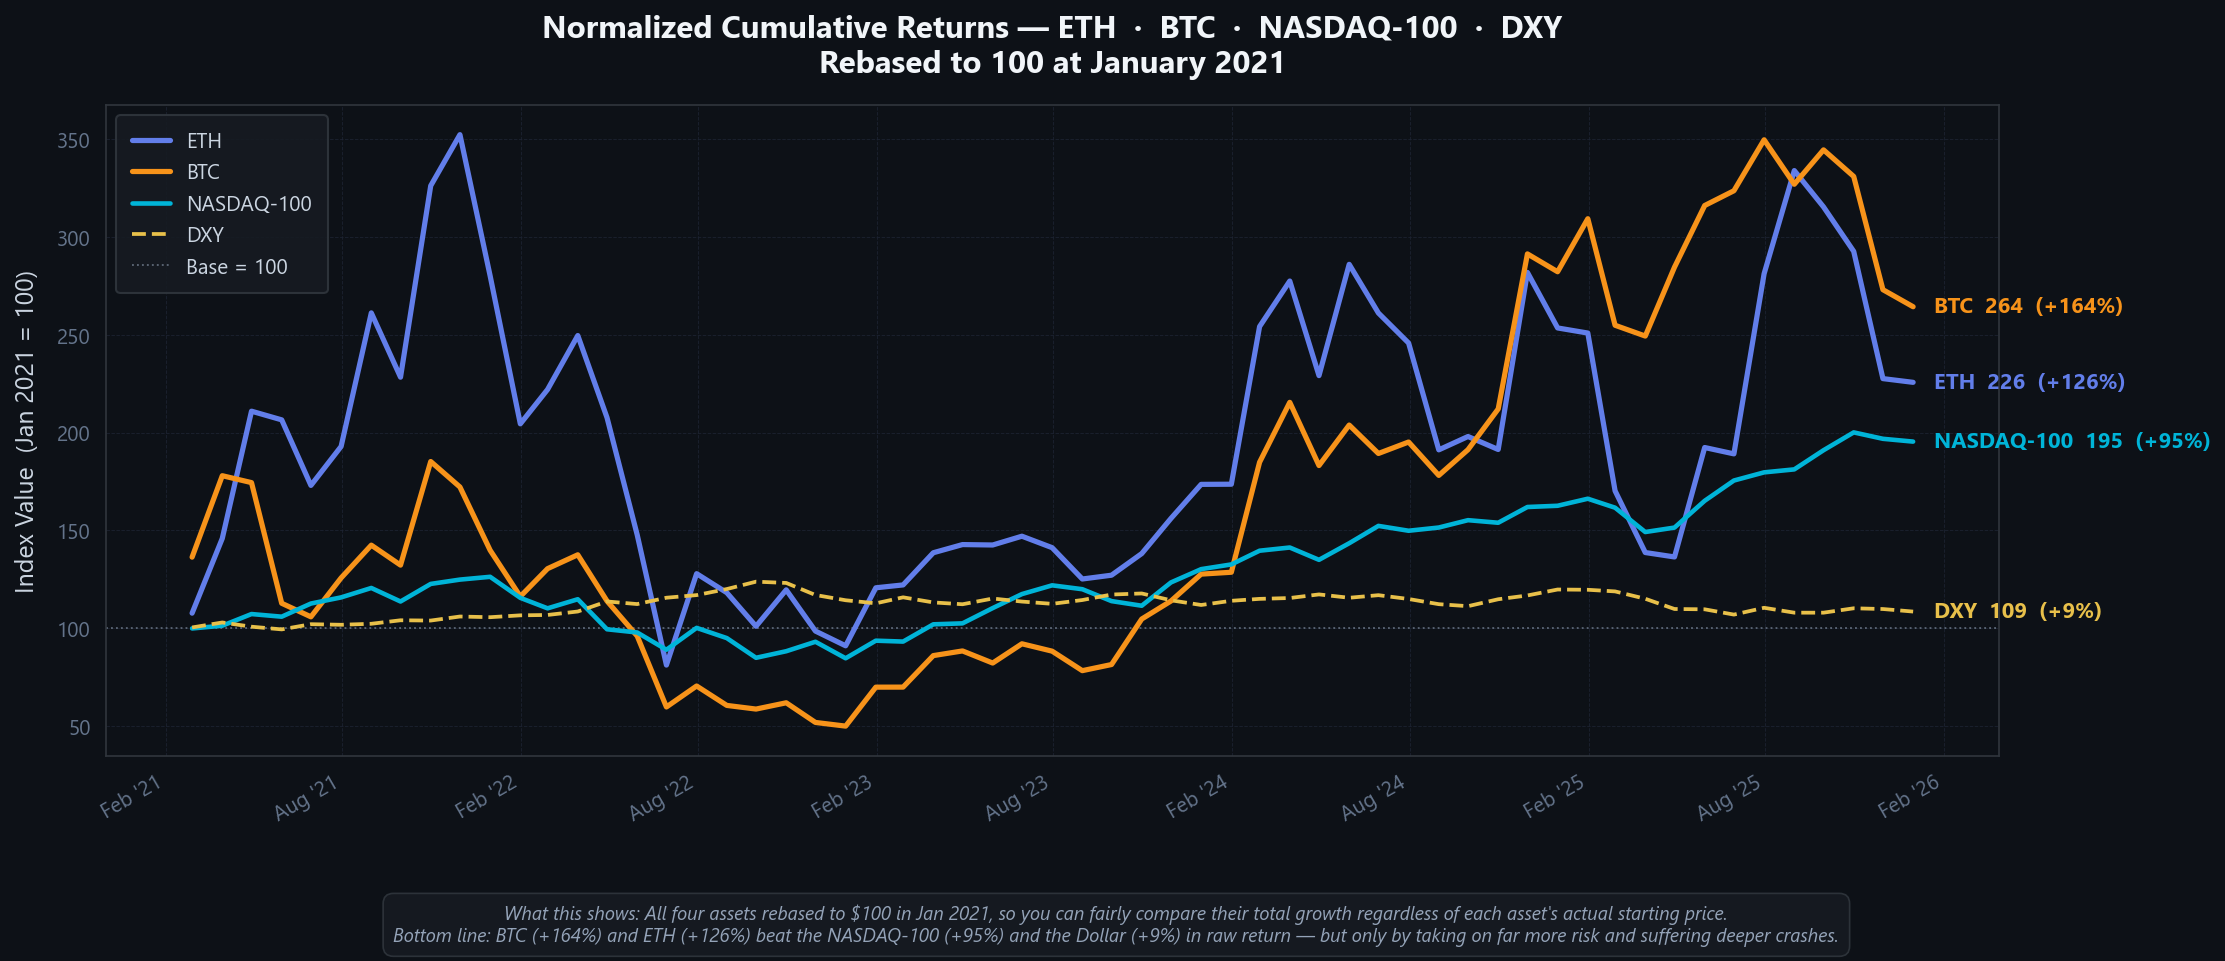

In [18]:
# ── Plot 7: Normalized Cumulative Returns (Rebased to 100 at Jan 2021) ────────
plot_config = [
    (ETH_TICKER,    PALETTE["eth"],    2.5, "-"),
    (BTC_TICKER,    PALETTE["btc"],    2.5, "-"),
    (NASDAQ_TICKER, PALETTE["nasdaq"], 2.2, "-"),
    (DXY_TICKER,    PALETTE["dxy"],    1.8, "--"),
]

fig, ax = plt.subplots(figsize=(15, 6.5))

for ticker, color, lw, ls in plot_config:
    cum = (1 + all_returns[ticker]).cumprod() * 100
    label = ASSET_LABELS[ticker]
    ax.plot(cum.index, cum, color=color, lw=lw, ls=ls, label=label, zorder=3)

    term = cum.iloc[-1]
    ax.annotate(
        f"{label}  {term:.0f}  ({term - 100:+.0f}%)",
        xy=(cum.index[-1], term),
        xytext=(10, 0), textcoords="offset points",
        color=color, fontsize=10.5, va="center", fontweight="bold",
    )

ax.axhline(100, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.55, label="Base = 100", zorder=2)

ax.set_title(
    "Normalized Cumulative Returns — ETH  ·  BTC  ·  NASDAQ-100  ·  DXY\n"
    "Rebased to 100 at January 2021",
)
ax.set_ylabel("Index Value  (Jan 2021 = 100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha="right")
ax.legend(loc="upper left")


_caption = (
    "What this shows: All four assets rebased to $100 in Jan 2021, so you can fairly compare their total growth regardless of each asset's actual starting price.\n"
    "Bottom line: BTC (+164%) and ETH (+126%) beat the NASDAQ-100 (+95%) and the Dollar (+9%) in raw return — but only by taking on far more risk and suffering deeper crashes."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("07_normalized_cumulative.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 8 — Annual Returns Comparison

Year-by-year geometric CAGRs for ETH, BTC, and NASDAQ-100 as grouped bars. DXY is deliberately excluded — its single-digit annual moves compress the axis and obscure the crypto/equity differences; it is better read in Part I Plot 3. Loss years are shown in red across all three assets.

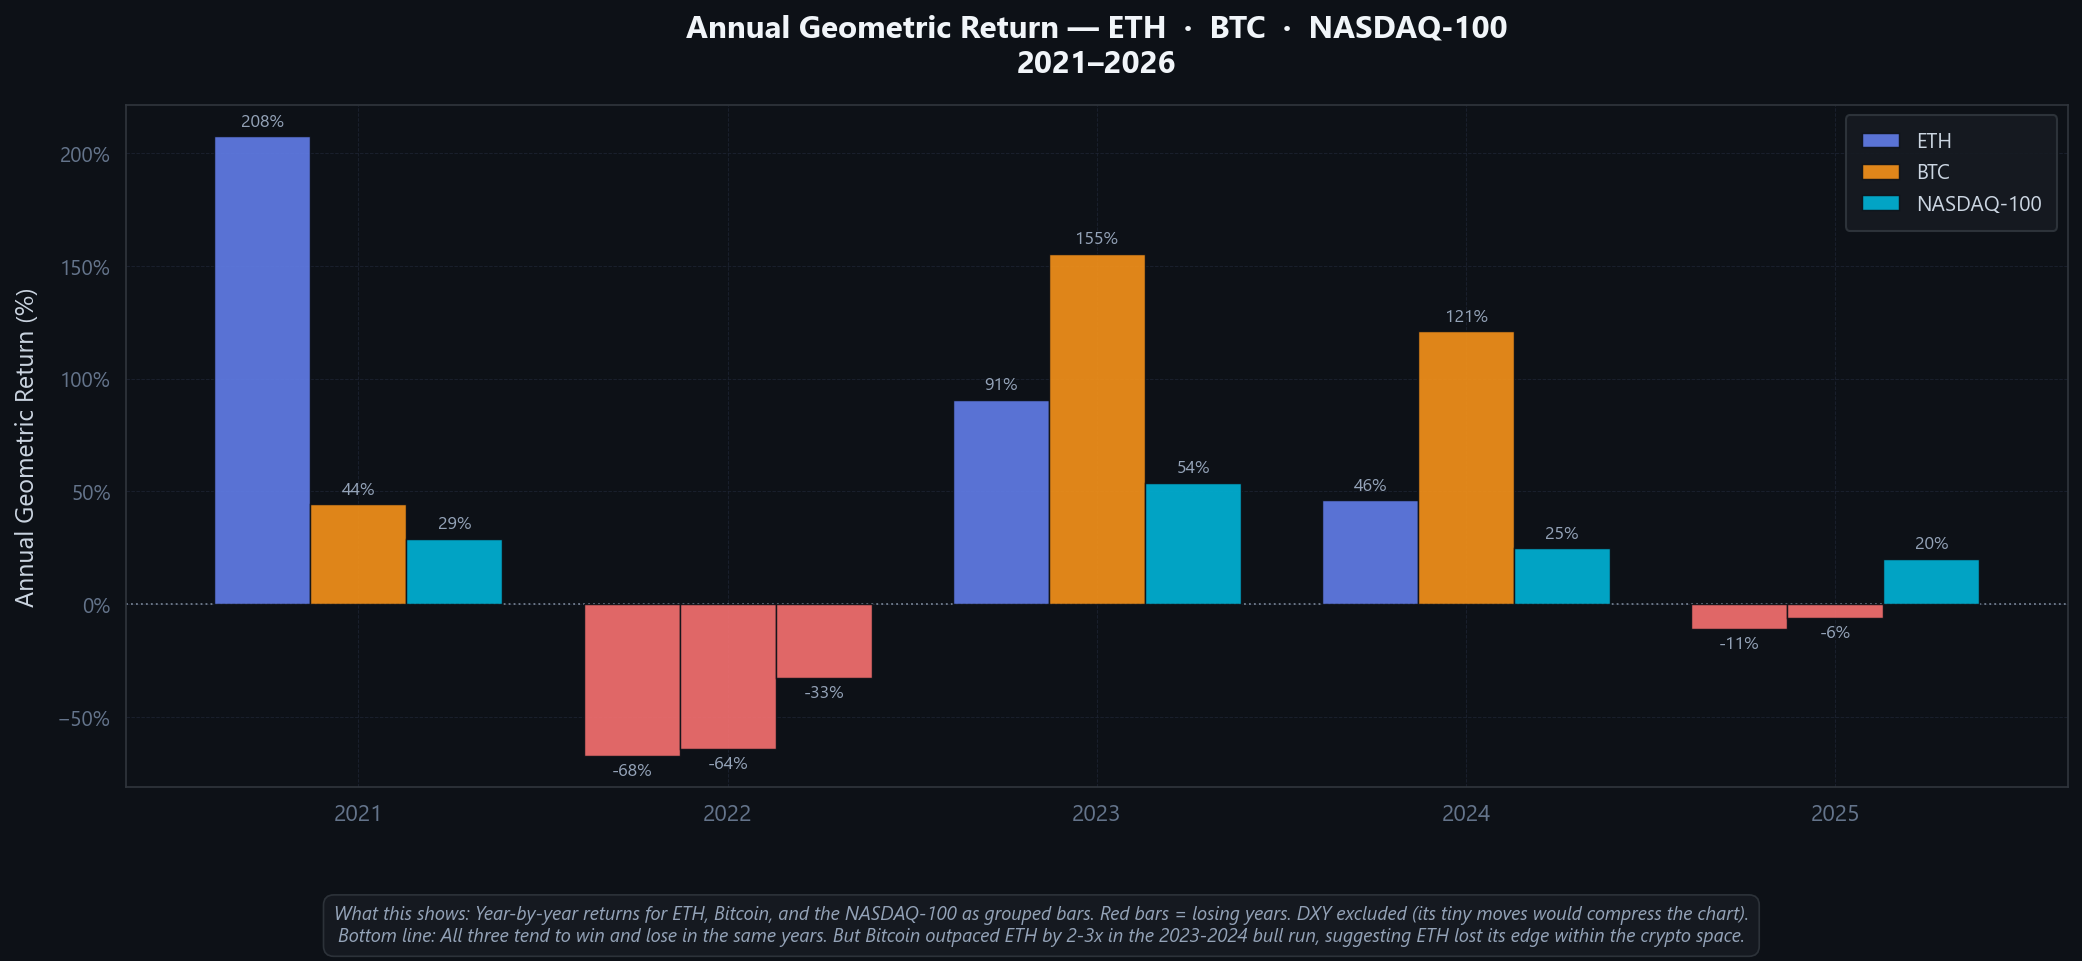

In [19]:
# ── Plot 8: Annual Returns Comparison — ETH vs BTC vs NASDAQ-100 ─────────────
# DXY is excluded: its single-digit magnitude makes it incompatible with the
# crypto/equity axis and is better read in Part I.
compare_tickers = [ETH_TICKER, BTC_TICKER, NASDAQ_TICKER]
compare_colors  = [PALETTE["eth"], PALETTE["btc"], PALETTE["nasdaq"]]
compare_labels  = [ASSET_LABELS[t] for t in compare_tickers]

annual_compare = compute_annual_returns(all_returns[compare_tickers])
years  = annual_compare.index.astype(str)
x      = np.arange(len(years))
width  = 0.26

fig, ax = plt.subplots(figsize=(14, 6.5))

for i, (ticker, color, label) in enumerate(zip(compare_tickers, compare_colors, compare_labels)):
    col    = f"{ticker}_geo"
    vals   = annual_compare[col] * 100
    offset = (i - 1) * width
    bar_colors = [PALETTE["negative"] if v < 0 else color for v in vals]

    bars = ax.bar(
        x + offset, vals,
        width=width, label=label,
        color=bar_colors, alpha=0.90,
        edgecolor="#0D1117", linewidth=0.7, zorder=3,
    )
    ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=8.5, color=PALETTE["neutral"])

ax.axhline(0, color=PALETTE["neutral"], lw=0.9, ls=":", alpha=0.7, zorder=2)
ax.set_title("Annual Geometric Return — ETH  ·  BTC  ·  NASDAQ-100\n2021–2026")
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel("Annual Geometric Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend()


_caption = (
    "What this shows: Year-by-year returns for ETH, Bitcoin, and the NASDAQ-100 as grouped bars. Red bars = losing years. DXY excluded (its tiny moves would compress the chart).\n"
    "Bottom line: All three tend to win and lose in the same years. But Bitcoin outpaced ETH by 2-3x in the 2023-2024 bull run, suggesting ETH lost its edge within the crypto space."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig("08_annual_comparison.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 9 — Risk–Return Scatter

Each asset is plotted at its **(annualised volatility, CAGR)** coordinate. Bubble area is proportional to |Sharpe| — a larger bubble signals a more efficient risk-adjusted return. The dashed Capital Market Line at Sharpe = 1.0 provides a reference benchmark: assets positioned above the line delivered more than 1 unit of return per unit of risk.

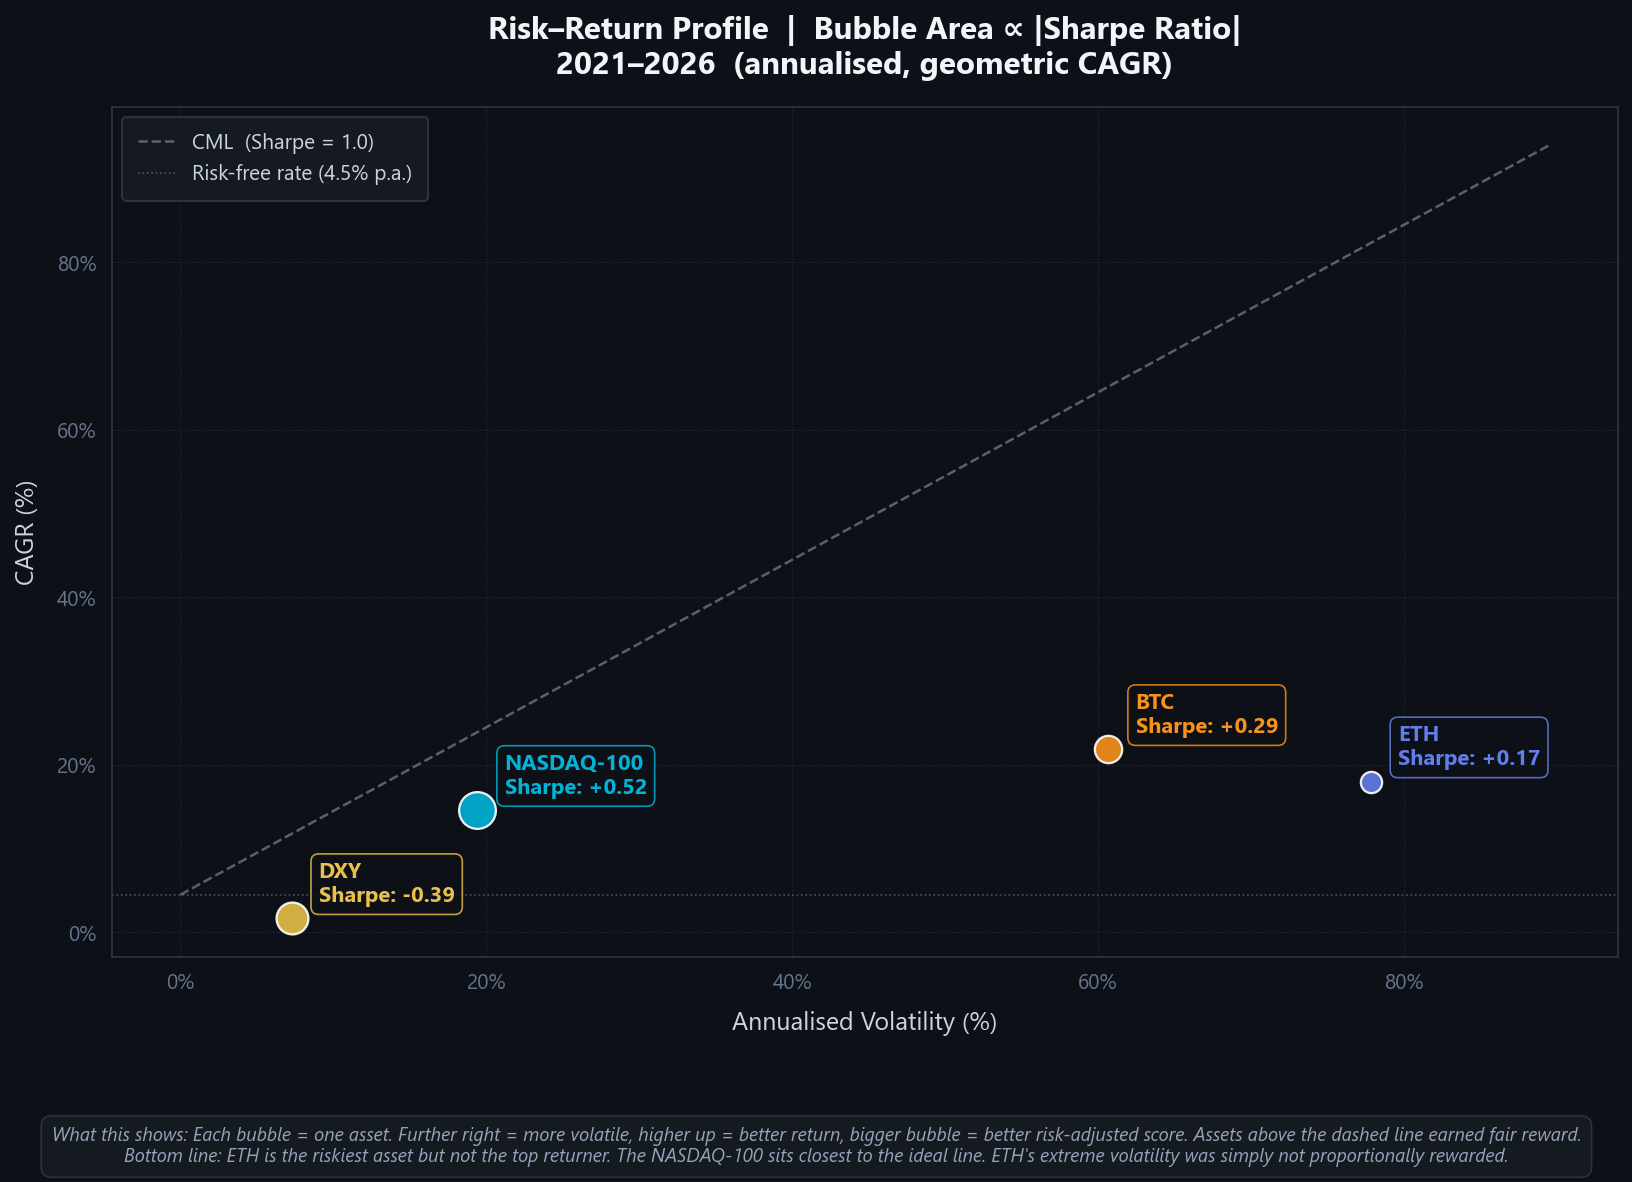

In [20]:
# ── Plot 9: Risk-Return Scatter (Bubble Size ∝ |Sharpe|) ──────────────────────
ticker_list  = list(all_returns.columns)
label_list   = [ASSET_LABELS[t]   for t in ticker_list]
color_list   = [PALETTE["eth"], PALETTE["btc"], PALETTE["dxy"], PALETTE["nasdaq"]]

fig, ax = plt.subplots(figsize=(11, 8))

for ticker, label, color in zip(ticker_list, label_list, color_list):
    m      = all_metrics[ticker]
    vol    = m["vol_annual"] * 100
    ret    = m["cagr"] * 100
    sharpe = m["sharpe"]
    size   = max(abs(sharpe) * 600, 80)

    ax.scatter(vol, ret, s=size, color=color, alpha=0.90, zorder=4,
               edgecolors="#FFFFFF", linewidths=1.1)
    ax.annotate(
        f"{label}\nSharpe: {sharpe:+.2f}",
        xy=(vol, ret),
        xytext=(13, 8), textcoords="offset points",
        fontsize=10.5, color=color, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", fc="#0D1117", ec=color, lw=0.8, alpha=0.82),
    )

# Capital Market Line: Sharpe = 1.0 reference
vol_max   = max(all_metrics[t]["vol_annual"] for t in ticker_list) * 115
vol_range = np.linspace(0, vol_max, 200)
rf_pct    = RISK_FREE_ANNUAL * 100
ax.plot(vol_range, rf_pct + 1.0 * vol_range,
        color=PALETTE["neutral"], lw=1.2, ls="--", alpha=0.55,
        label="CML  (Sharpe = 1.0)", zorder=2)
ax.axhline(rf_pct, color=PALETTE["neutral"], lw=0.8, ls=":", alpha=0.45, zorder=2,
           label=f"Risk-free rate ({RISK_FREE_ANNUAL:.1%} p.a.)")

ax.set_title(
    "Risk–Return Profile  |  Bubble Area ∝ |Sharpe Ratio|\n"
    "2021–2026  (annualised, geometric CAGR)",
)
ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel("CAGR (%)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend()


_caption = (
    "What this shows: Each bubble = one asset. Further right = more volatile, higher up = better return, bigger bubble = better risk-adjusted score. Assets above the dashed line earned fair reward.\n"
    "Bottom line: ETH is the riskiest asset but not the top returner. The NASDAQ-100 sits closest to the ideal line. ETH's extreme volatility was simply not proportionally rewarded."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.savefig("09_risk_return.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 10 — Multi-Asset Drawdown Comparison

Three stacked underwater panels for ETH, BTC, and NASDAQ-100. Comparing the panels vertically reveals whether drawdowns were **synchronised** (the same macro shock) or **idiosyncratic** (asset-specific). Maximum drawdown date and magnitude are annotated in each panel.

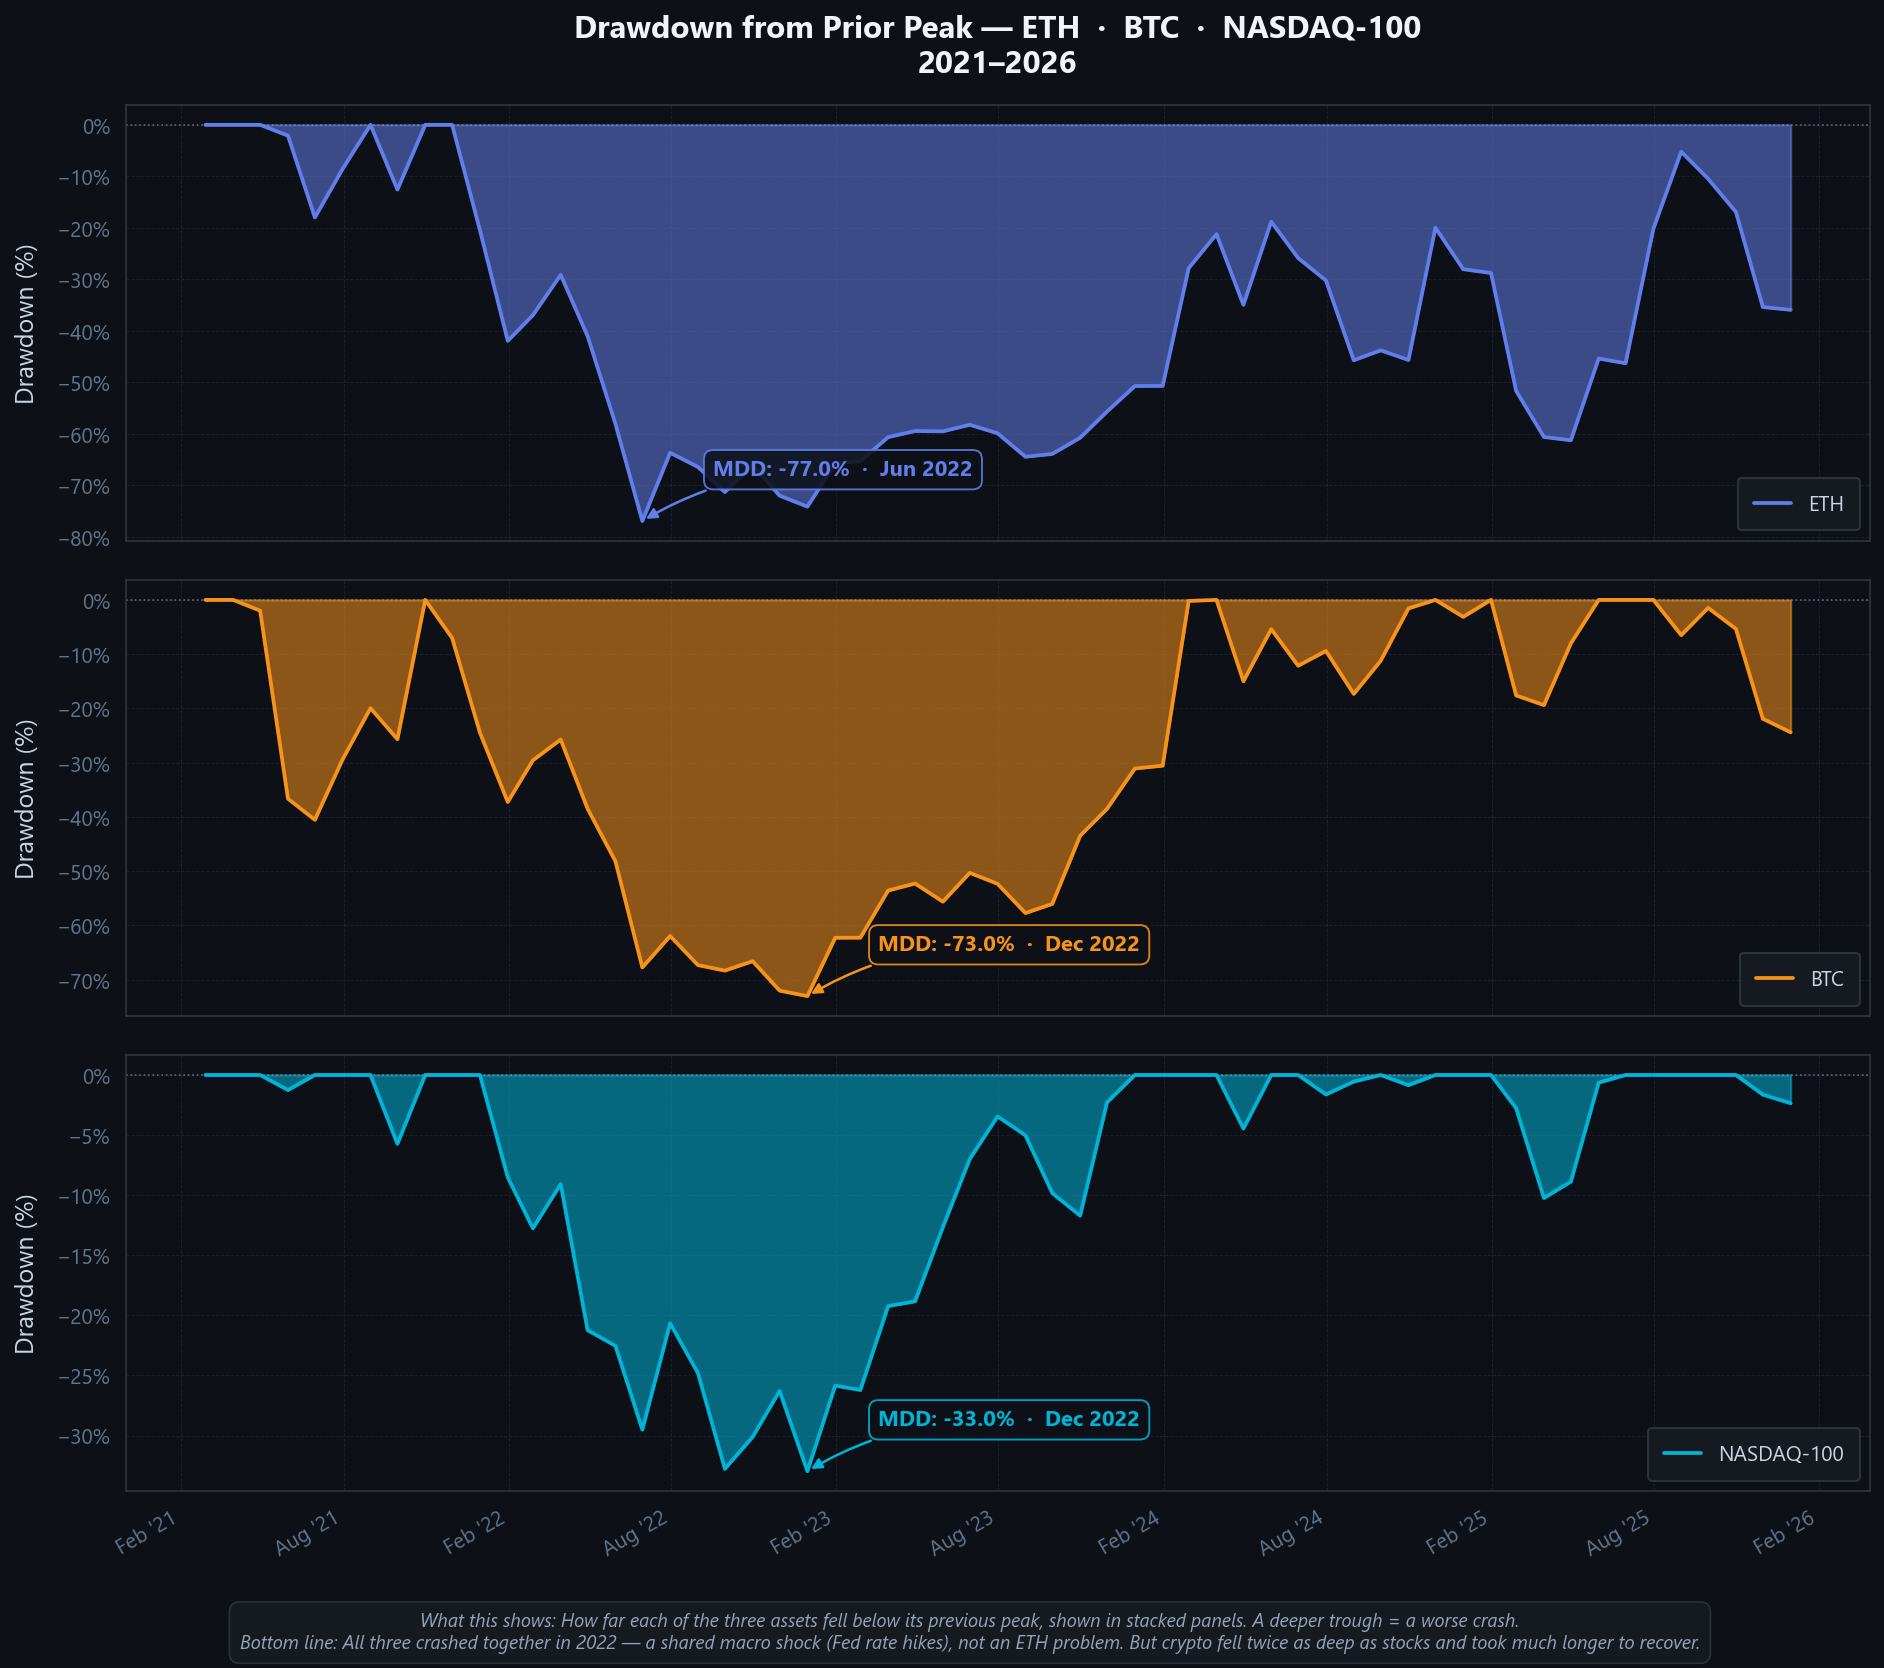

In [21]:
# ── Plot 10: Multi-Asset Drawdown Comparison ──────────────────────────────────
compare_dd = [
    (ETH_TICKER,    PALETTE["eth"],    "ETH"),
    (BTC_TICKER,    PALETTE["btc"],    "BTC"),
    (NASDAQ_TICKER, PALETTE["nasdaq"], "NASDAQ-100"),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True,
                          gridspec_kw={"hspace": 0.09})

for ax, (ticker, color, label) in zip(axes, compare_dd):
    dd = all_metrics[ticker]["drawdown_series"] * 100
    # Dual-layer fill: solid core + soft glow
    ax.fill_between(dd.index, dd, 0, alpha=0.48, color=color, zorder=2)
    ax.fill_between(dd.index, dd, 0, alpha=0.12, color=color, zorder=1)
    ax.plot(dd.index, dd, color=color, lw=1.8, label=label, zorder=3)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8, ls=":", alpha=0.6, zorder=2)

    mdd_date = dd.idxmin()
    mdd_val  = dd.min()
    ax.annotate(
        f"MDD: {mdd_val:.1f}%  ·  {mdd_date.strftime('%b %Y')}",
        xy=(mdd_date, mdd_val),
        xytext=(34, 22), textcoords="offset points",
        color=color, fontsize=10.5, fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.2,
                        connectionstyle="arc3,rad=0.15"),
        bbox=dict(boxstyle="round,pad=0.42", fc="#0D1117", ec=color,
                  lw=0.9, alpha=0.88),
    )
    ax.set_ylabel("Drawdown (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(loc="lower right")
    ax.spines["bottom"].set_color(_EDGE)

axes[0].set_title(
    "Drawdown from Prior Peak — ETH  ·  BTC  ·  NASDAQ-100\n2021–2026",
)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha="right")


_caption = (
    "What this shows: How far each of the three assets fell below its previous peak, shown in stacked panels. A deeper trough = a worse crash.\n"
    "Bottom line: All three crashed together in 2022 — a shared macro shock (Fed rate hikes), not an ETH problem. But crypto fell twice as deep as stocks and took much longer to recover."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("10_multi_drawdown.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 11 — Pairwise Correlation Heatmap

Lower-triangle Pearson correlation matrix of monthly log returns for all four assets. The `**`, `*`, and `ns` markers denote statistical significance at p < 0.01, p < 0.05, and not significant respectively. A strong ETH–BTC correlation confirms they belong to the same asset class; a growing ETH–NASDAQ correlation would suggest increasing institutional overlap.

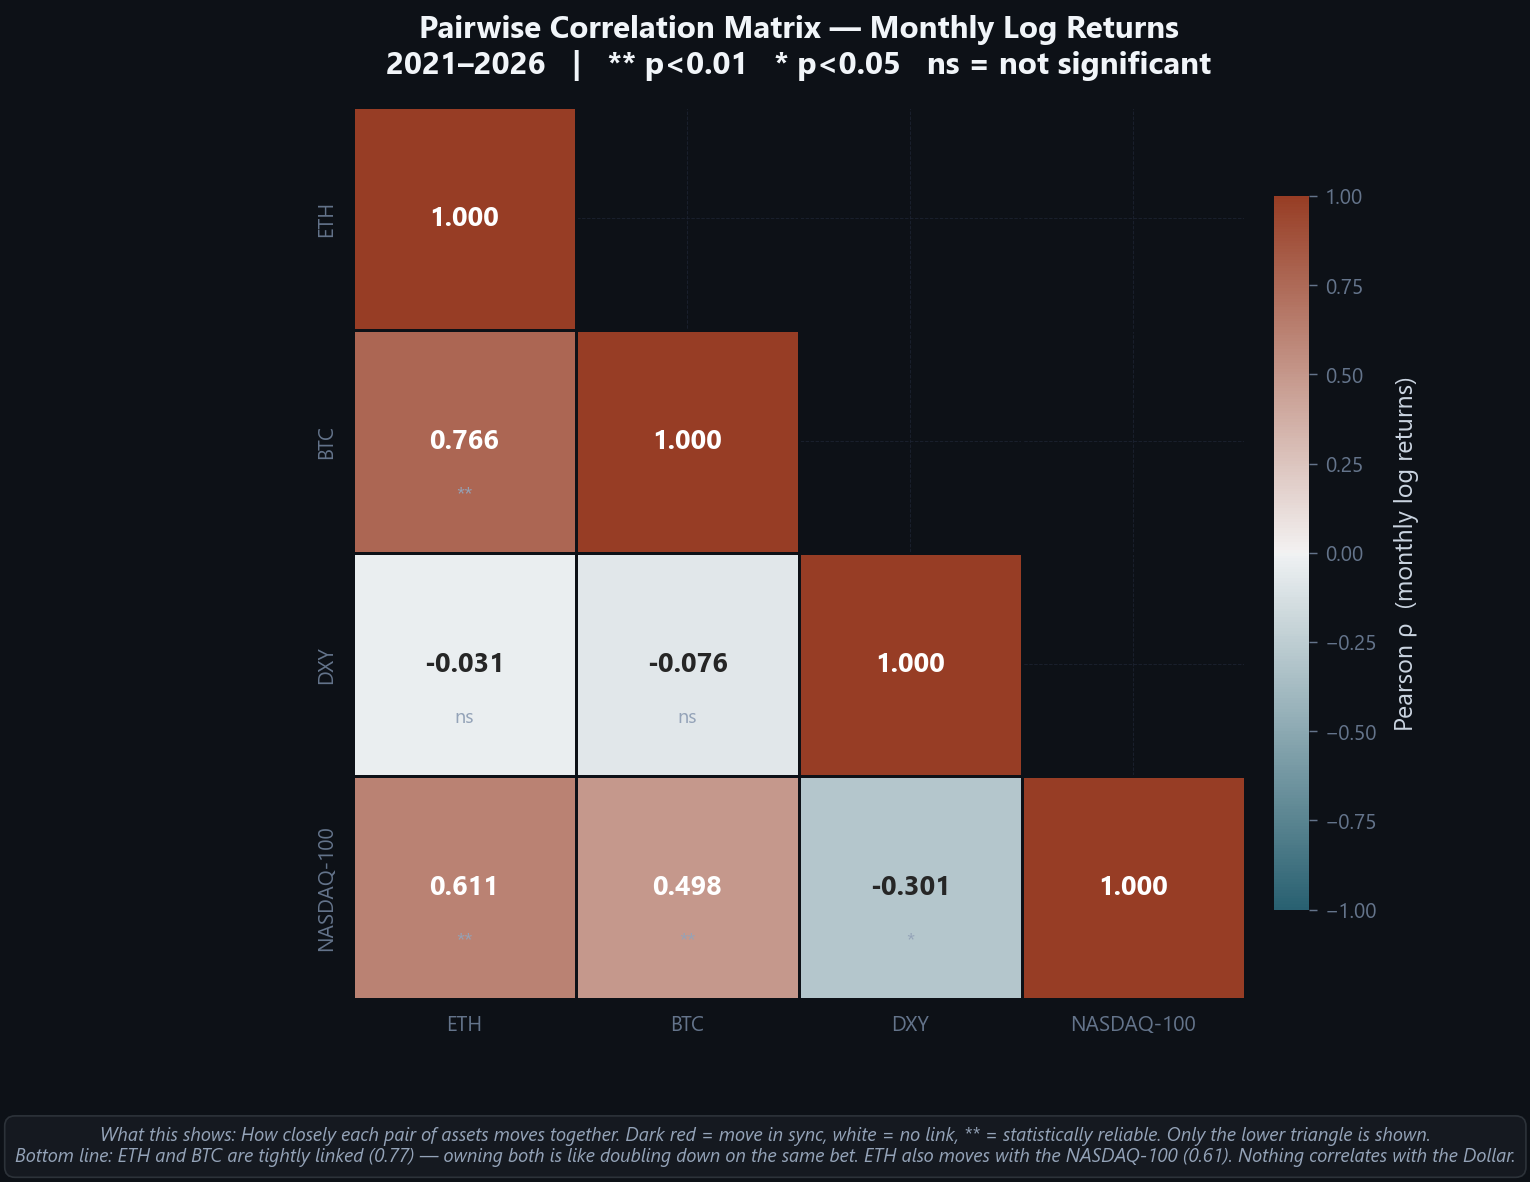

In [22]:
# ── Plot 11: Pairwise Correlation Heatmap ─────────────────────────────────────
log_ret_all = np.log(1 + all_returns)
corr_matrix = log_ret_all.corr()
corr_matrix.columns = [ASSET_LABELS[c] for c in corr_matrix.columns]
corr_matrix.index   = [ASSET_LABELS[c] for c in corr_matrix.index]

# Compute p-values for each pair
raw_cols = list(log_ret_all.columns)
p_matrix = pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns, dtype=float)
for i, ci in enumerate(raw_cols):
    for j, cj in enumerate(raw_cols):
        if i == j:
            p_matrix.iloc[i, j] = 0.0
        else:
            _, pv = stats.pearsonr(log_ret_all[ci].dropna(), log_ret_all[cj].dropna())
            p_matrix.iloc[i, j] = pv

# Show only lower triangle (upper triangle masked)
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap=sns.diverging_palette(220, 20, s=80, l=38, as_cmap=True),
    center=0, vmin=-1, vmax=1,
    square=True,
    linewidths=0.6, linecolor="#0D1117",
    mask=mask_upper, ax=ax,
    annot_kws={"size": 13, "weight": "bold"},
    cbar_kws={"label": "Pearson ρ  (monthly log returns)", "shrink": 0.80, "pad": 0.02},
)

# Overlay significance markers below the correlation value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        if i > j:
            pv = p_matrix.iloc[i, j]
            sig = "**" if pv < 0.01 else ("*" if pv < 0.05 else "ns")
            ax.text(
                j + 0.5, i + 0.74, sig,
                ha="center", va="center",
                fontsize=9.5, color="#94A3B8",
            )

ax.set_title(
    "Pairwise Correlation Matrix — Monthly Log Returns\n"
    "2021–2026   |   ** p<0.01   * p<0.05   ns = not significant",
)
ax.tick_params(left=False, bottom=False)

_caption = (
    "What this shows: How closely each pair of assets moves together. Dark red = move in sync, white = no link, ** = statistically reliable. Only the lower triangle is shown.\n"
    "Bottom line: ETH and BTC are tightly linked (0.77) — owning both is like doubling down on the same bet. ETH also moves with the NASDAQ-100 (0.61). Nothing correlates with the Dollar."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.savefig("11_correlation_heatmap.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 12 — Rolling Correlations

12-month rolling Pearson ρ for two key pairs: **ETH–BTC** (top) and **ETH–NASDAQ-100** (bottom). Green fill = positive co-movement; red fill = inverse relationship. The dashed line marks the full-period average ρ. A trend toward higher ETH–NASDAQ correlation over time would indicate that crypto is increasingly trading as a risk-on equity proxy rather than an independent asset class.

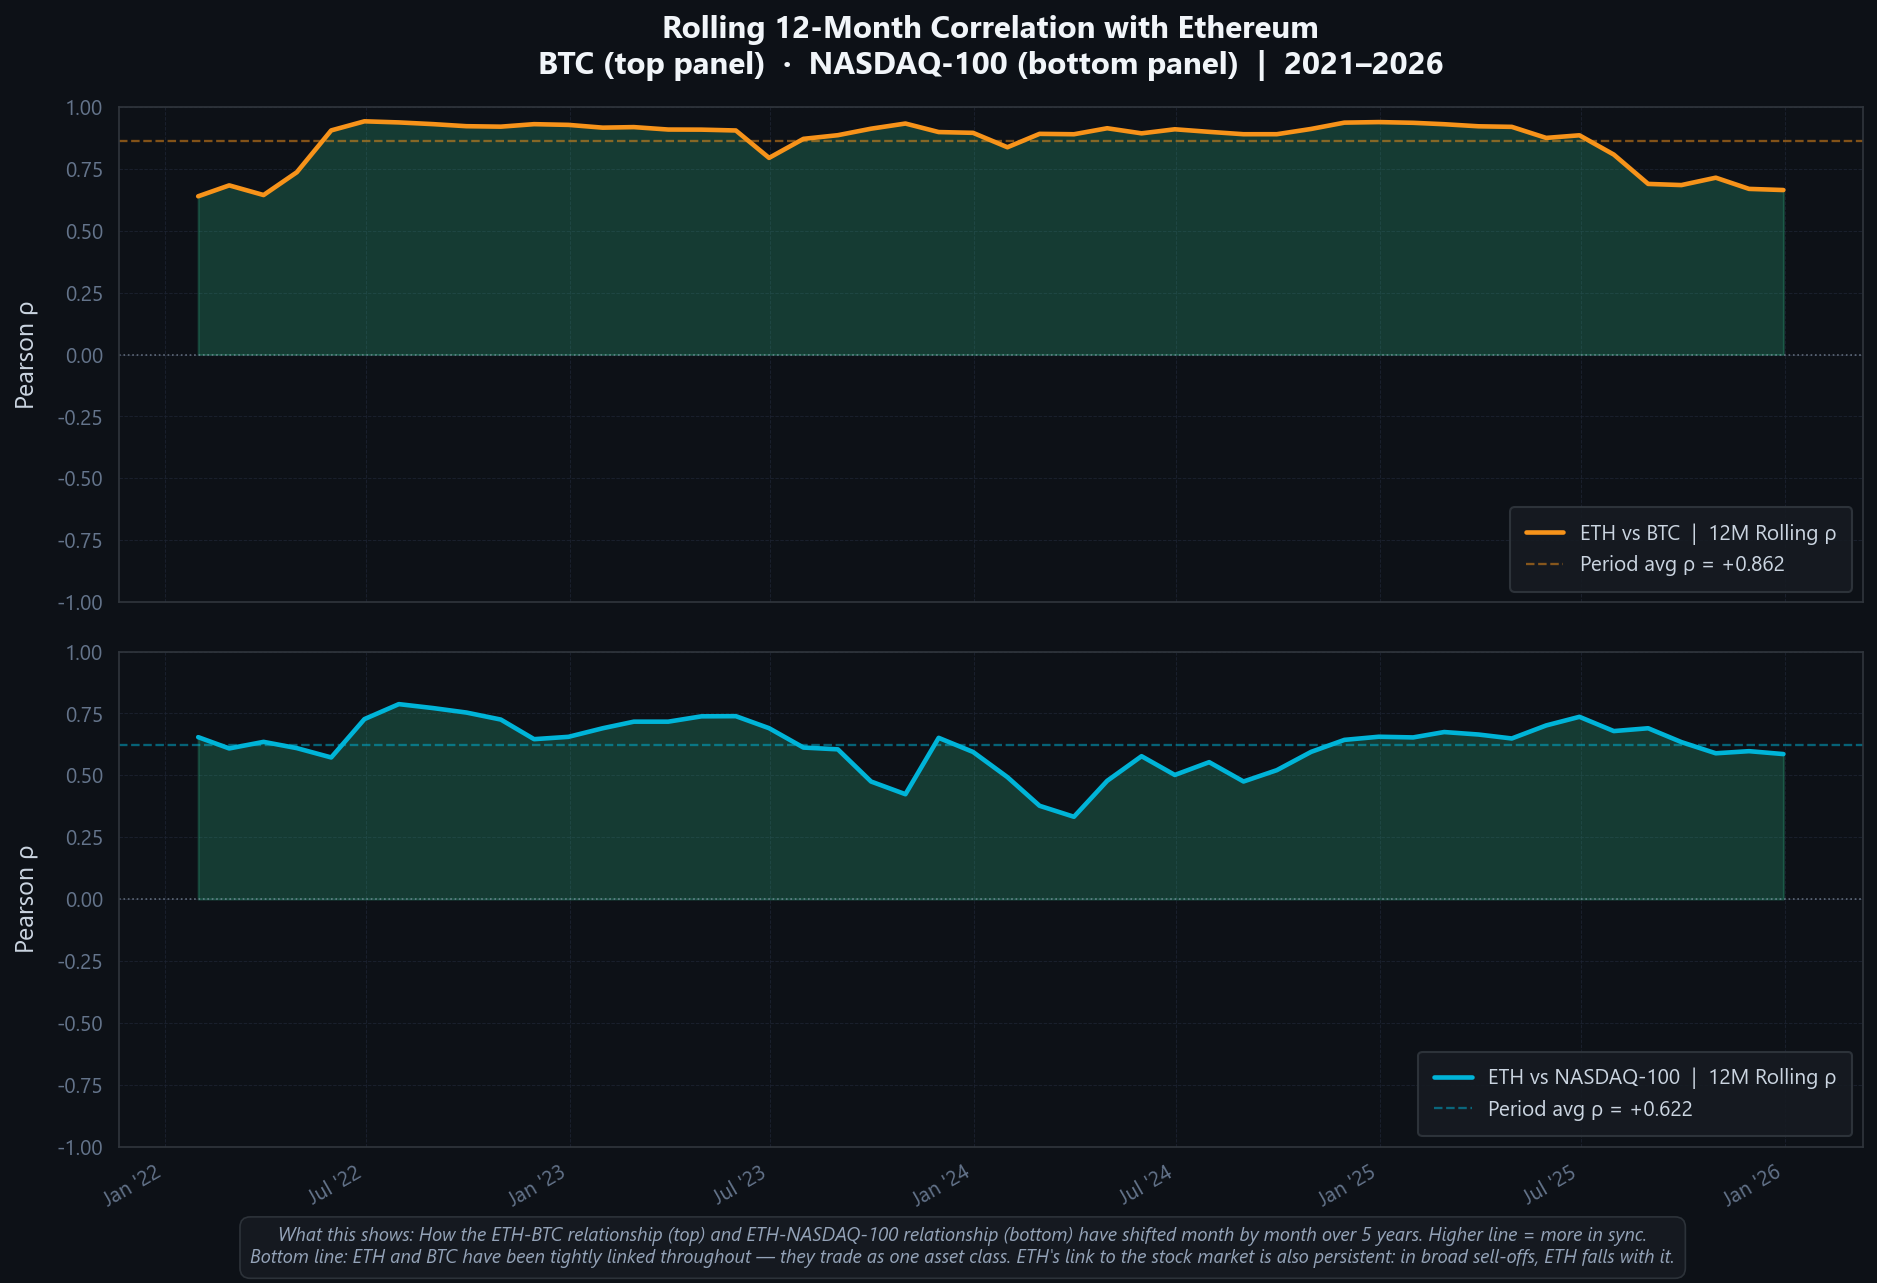

In [23]:
# ── Plot 12: Rolling Correlations — ETH vs BTC and ETH vs NASDAQ-100 ──────────
eth_log = np.log(1 + all_returns[ETH_TICKER])
btc_log = np.log(1 + all_returns[BTC_TICKER])
nas_log = np.log(1 + all_returns[NASDAQ_TICKER])

roll_eth_btc = eth_log.rolling(ROLLING_WINDOW).corr(btc_log)
roll_eth_nas = eth_log.rolling(ROLLING_WINDOW).corr(nas_log)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                          gridspec_kw={"hspace": 0.10})

panels = [
    (axes[0], roll_eth_btc, PALETTE["btc"],    "ETH vs BTC"),
    (axes[1], roll_eth_nas, PALETTE["nasdaq"], "ETH vs NASDAQ-100"),
]

for ax, series, color, label in panels:
    rc = series.dropna()
    ax.fill_between(rc.index, rc, 0, where=(rc >= 0), alpha=0.22, color=PALETTE["positive"], zorder=2)
    ax.fill_between(rc.index, rc, 0, where=(rc <  0), alpha=0.22, color=PALETTE["negative"], zorder=2)
    ax.plot(rc.index, rc, color=color, lw=2.2,
            label=f"{label}  |  {ROLLING_WINDOW}M Rolling ρ", zorder=3)
    ax.axhline(0,         color=PALETTE["neutral"], lw=0.8, ls=":", alpha=0.6, zorder=2)
    ax.axhline(rc.mean(), color=color, lw=1.1, ls="--", alpha=0.50, zorder=2,
               label=f"Period avg ρ = {rc.mean():+.3f}")
    ax.set_ylim(-1, 1)
    ax.set_ylabel("Pearson ρ")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.legend(loc="lower right")
    ax.spines["bottom"].set_color(_EDGE)

axes[0].set_title(
    f"Rolling {ROLLING_WINDOW}-Month Correlation with Ethereum\n"
    "BTC (top panel)  ·  NASDAQ-100 (bottom panel)  |  2021–2026",
)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")


_caption = (
    "What this shows: How the ETH-BTC relationship (top) and ETH-NASDAQ-100 relationship (bottom) have shifted month by month over 5 years. Higher line = more in sync.\n"
    "Bottom line: ETH and BTC have been tightly linked throughout — they trade as one asset class. ETH's link to the stock market is also persistent: in broad sell-offs, ETH falls with it."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.09, 1, 1])
plt.savefig("12_rolling_correlations.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Plot 13 — Performance Metrics Summary Table

A styled side-by-side table of the six core risk-adjusted metrics for all four assets. Column headers are colour-coded with the asset palette used throughout the notebook (ETH purple · BTC orange · DXY gold · NASDAQ cyan), making it easy to scan across rows and draw direct comparisons.

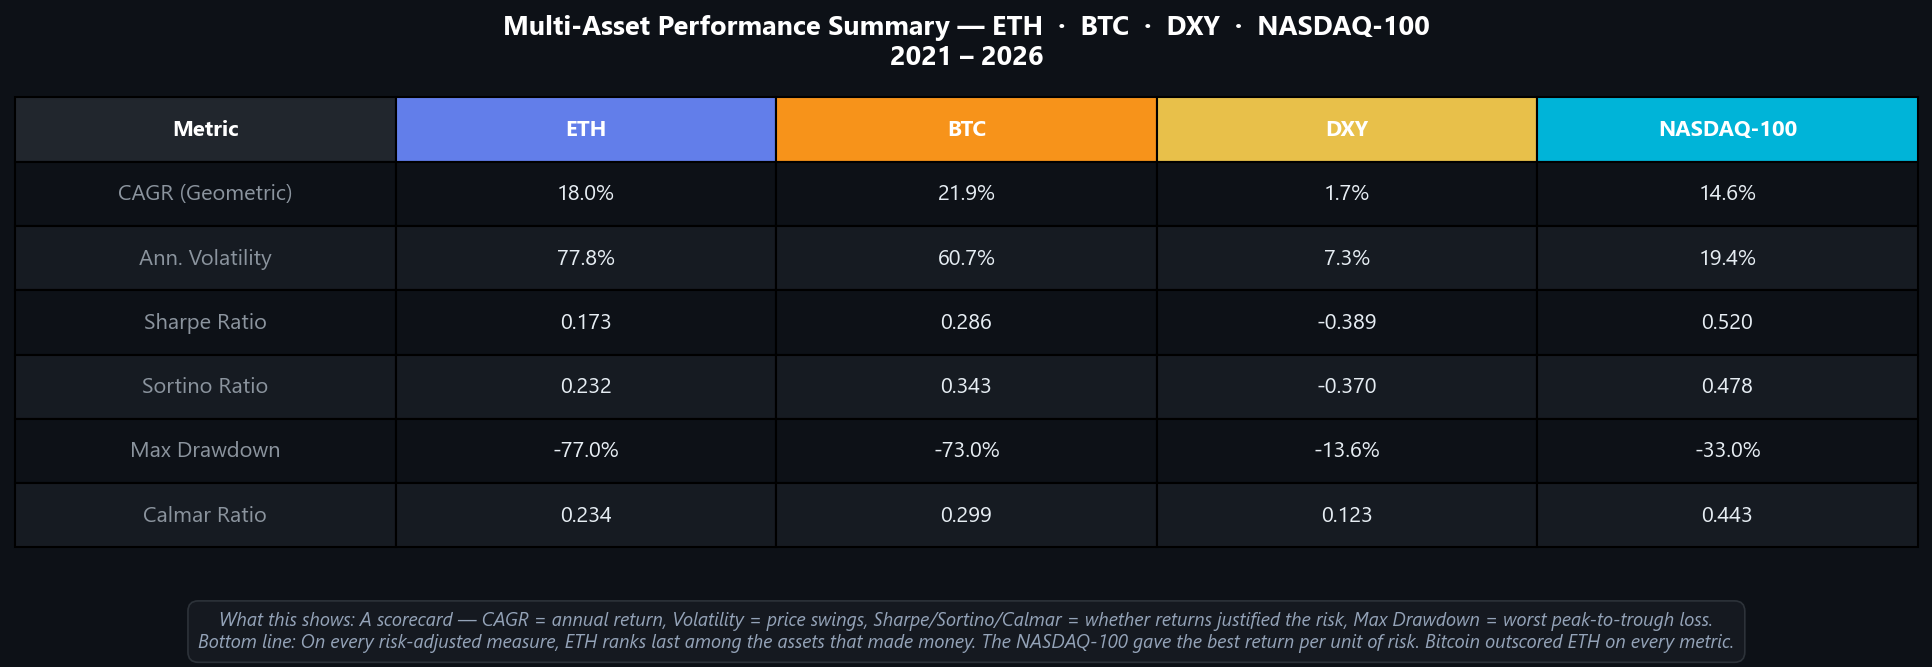

In [24]:
# ── Plot 13: Multi-Asset Performance Comparison — Visual Metrics Table ────────
display_tickers = list(all_returns.columns)
display_labels  = [ASSET_LABELS[t] for t in display_tickers]
asset_colors    = [PALETTE["eth"], PALETTE["btc"], PALETTE["dxy"], PALETTE["nasdaq"]]

metrics_display = [
    ("CAGR (Geometric)",  "cagr",         True),
    ("Ann. Volatility",   "vol_annual",   True),
    ("Sharpe Ratio",      "sharpe",       False),
    ("Sortino Ratio",     "sortino",      False),
    ("Max Drawdown",      "max_drawdown", True),
    ("Calmar Ratio",      "calmar",       False),
]

table_data = []
for disp_name, key, is_pct in metrics_display:
    row = [disp_name]
    for t in display_tickers:
        val = all_metrics[t][key]
        row.append(f"{val:.1%}" if is_pct else f"{val:.3f}")
    table_data.append(row)

col_labels = ["Metric"] + display_labels

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)

# Header row
col_header_colors = ["#21262D"] + asset_colors
for j, color in enumerate(col_header_colors):
    cell = table[0, j]
    cell.set_facecolor(color)
    cell.set_text_props(color="#FFFFFF", fontweight="bold")

# Data rows — alternating dark backgrounds, metric name in muted colour
for i in range(1, len(table_data) + 1):
    row_bg = "#161B22" if i % 2 == 0 else "#0D1117"
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_facecolor(row_bg)
        cell.set_text_props(color="#8B949E" if j == 0 else "#E6EDF3")

ax.set_title(
    "Multi-Asset Performance Summary — ETH  ·  BTC  ·  DXY  ·  NASDAQ-100\n2021 – 2026",
    fontsize=13, pad=16, color="#FFFFFF",
)

_caption = (
    "What this shows: A scorecard — CAGR = annual return, Volatility = price swings, Sharpe/Sortino/Calmar = whether returns justified the risk, Max Drawdown = worst peak-to-trough loss.\n"
    "Bottom line: On every risk-adjusted measure, ETH ranks last among the assets that made money. The NASDAQ-100 gave the best return per unit of risk. Bitcoin outscored ETH on every metric."
)
fig.text(
    0.5, 0.02, _caption,
    ha="center", va="bottom", fontsize=9.0, color="#94A3B8", style="italic",
    bbox=dict(boxstyle="round,pad=0.55", fc="#161B22", ec="#30363D", lw=0.8, alpha=0.90),
    transform=fig.transFigure,
)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.savefig("13_metrics_table.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()